<a href="https://colab.research.google.com/github/fatemehmsh90/Business-Data-Analytics-Project/blob/main/FINAL_IBS_PROJECT_FATEMEH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Drug Substitute Identification and Risk Analysis in the Pharmaceutical Supply Chain Using Data-Driven Similarity and Exploratory Analytics**
**Programme:** MSc IT – Business Data Analytics

**Author:** Fatemeh Mashayekhiahangarani
  
**Repo:** Business-Data-Analytics-Project  

> This notebook contains the analysis, figures, and notes used for the dissertation.  
> Final report will be a separate PDF (uploaded to Moodle). Code and figures are saved here.

---


##**EXECUTIVE SUMMARY**

This project aims to introduce a data-driven system that can identify suitable alternative drugs in times of drug shortage. Drug shortages are a growing problem in many healthcare systems, and finding suitable alternatives is of great importance to patients, hospitals, and supply chain managers. The goal of this study was to build a simple, explainable and reproducible model that can help suggest substitute drugs by using the large MID dataset and modern text-embedding methods.

The work began with preparing and cleaning the dataset. The MID data includes medicine names, descriptions, therapeutic classes, and other structured fields. A combined text field was created for each medicine by merging different description parts. This helped capture more information in a single representation. Basic exploratory analysis showed that the dataset is large, diverse, and suitable for building a similarity-based model.

The methodology used two main feature types: text features and structured features. For the text part, a light Sentence-BERT model (MiniLM-L6-v2) was used to create embeddings. For the structured part, one-hot encoding was applied to fields such as chemical class and therapeutic class. These two sets of features were then merged into one combined vector for each medicine. A cosine-similarity matrix and clustering methods were used to explore relationships between medicines.

Model evaluation, including external validation with the Kaggle dataset, was also performed at the suggestion of the supervisor to increase the accuracy of the proposed model. However, the model could still find general similarity patterns. Metrics such as Hit@k and Precision@k showed low scores for exact substitutes, but the behaviour matched expectations given the differences between datasets.

A sensitivity analysis showed that text features are better for finding close substitutes, while structured features are better for grouping medicines into broader categories. This supported the decision to use a combined model. A substitution network graph was built to reveal strong similarity links, and two new indicators were introduced. The Substitutability Index (SI) measures how many alternatives each drug has, and the Shortage Risk Index (SRI) shows how vulnerable a drug is when substitutes are limited.

The results showed that some medicines, such as common antibiotics, have many alternatives, while others, such as eye drops and special-use injections, have almost no substitutes. These findings can help managers identify high-risk products and plan better during shortages. A simple Python-based dashboard concept was also created to show how these results can be used in practice.
Overall, the project demonstrates that combining text and structured data can support decision-making in pharmaceutical supply chains, especially for shortage management and risk assessment.

# **CHAPTER 1 – INTRODUCTION**

## **1.1	BACKGROUND OF THE STUDY**

In today’s world, drug shortages have gone from being a simple issue to a chronic problem. When a drug becomes scarce or out of stock, the primary response from suppliers is to find and replace it with another drug. In the past, this was done by manual search and over-reliance on humans, which resulted in slow substitution processes and even errors in selecting the replacement drug.

Today's substitution methods are mostly based on the active ingredient of the drug. This one-dimensional selection method ignores other fundamental factors such as chemical structure, mode of action, or side effects that are very important in determining the choice of a substitute drug. For companies which working on medicines, this type of selection can be dangerous because choosing the wrong substitute not only means reduced or no sales of the drug, but can also lead to legal liabilities, including financial and life-threatening losses to patients (Aronson et al., 2023a; Aronson et al., 2023b).

Although pharmaceutical supply chain problems, from raw material shortages to over-reliance on a particular manufacturer, have been well addressed in previous research (Andy and Andy, 2023), the main solution to this problem seems to lie in the way information is processed. Traditional ERP systems in pharmacies are mostly descriptive in nature, meaning they only have the ability to tell us whether a drug is available or not, but they are not intelligent enough to suggest what can replace a rare or scarce drug. By using advanced data-driven techniques, especially Text Embeddings and Structural Similarity, we can turn existing pharmaceutical data into a tool for decision-making (Kauffman et al., 2025). In this study, Kauffman shows that he and his colleagues were able to design and build a multi-dimensional similarity measurement system that helps pharmaceutical managers make quick, data-driven choices in emergency situations.



## **1.2	PROBLEM STATEMENT**

Currently, the pharmaceutical supply chain is facing a serious crisis. While the problem of drug shortages is increasing day by day, there is little standard data-driven system that can fully automatically identify alternative drugs. In practice, pharmaceutical actors are forced to rely on manual searches or their previous experiences or experts in this field, which will lead to the Business Dilemma, one is the slow decision-making process in critical situations and the other is the lack of accuracy in systems that only match drugs based on the active ingredient of the drugs and ignore the complex relationships between the chemical structure, mechanism of action and therapeutic use of drugs.

In terms of management, a process based on trial and error is not only inefficient but can also carry high risks in various aspects. Choosing alternative drugs over systems that operate solely on the basis of the active ingredient can lead to tension in the supply chain, non-compliance with the regulations and standards of organizations overseeing the drug supply process, as well as loss of trust among doctors, pharmacies, and hospitals.

***Therefore, the main problem of this study is:***

How can we integrate multiple textual data and chemical and therapeutic properties to create a highly accurate model, and how can we translate these analytical outputs into actionable business insights to mitigate risks from drug shortages?

As we have said, although there are some traditional databases for drug substitution that have been used in various centers, their function is mainly as static search tools that require human interpretation and manual reviews. The business value of our proposed system is that it has passed from the "information retrieval" stage to the "intelligent recommendation" stage and, by integrating multidimensional data, provides a Quantified Score that reduces the mental burden of managers and decreases the risk of human errors in critical situations. This automation not only speeds up the purchasing process, but also ensures that the substitution decisions made are aligned with both "therapeutic safety" and "supply chain efficiency". This creates a competitive advantage in the current market.


## **1.3	RESEARCH AIM AND OBJECTIVES**
**Research Aim:**

The main point of this thesis is to develop an advanced, multidimensional framework for identifying alternative drugs by integrating textual data with drug characteristics. In this study, we have attempted to move beyond simple keyword matching to create a data-driven decision support tool that helps pharmaceutical executives mitigate the effects of drug shortages through high-accuracy similarity modeling.

**Research Objectives:**

1.	Develop Semantic Representations:

To generate high-dimensional text embeddings from drug descriptions, capturing the semantic meaning of clinical and pharmaceutical narratives.

2.	Encode Multimodal Structural Features:

To systematically encode structured categorical data, including therapeutic classes, chemical structures, and mechanisms of action.

3. Implement Dimensionality Reduction and Optimization:

To address high-dimensionality challenges using techniques like PCA and to determine the optimal cluster configurations (k-selection) through Systematic Optimization (Elbow and Silhouette methods).

4. Synthesize Feature Fusion:

To integrate textual and structured vectors into a unified similarity matrix using Cosine Similarity for robust substitute identification.

5. Map the Substitution Network:

To identify Top-k substitutes and visualize the drug landscape through clustering and network analysis to identify substitution "hubs".

6. Develop Managerial KPIs:

To construct the Substitutability Index (SI) and Shortage Risk Index (SRI) as concrete business metrics for evaluating supply chain vulnerability.

7. Validate via External Benchmarking:

To rigorously evaluate the model’s performance using an external validation dataset through precision-based metrics.

## **1.4	RESEARCH QUESTIONS**

This study seeks to answer the following basic questions:

**RQ1: Technical integration**

How does embedding text structures with drug properties such as therapeutic class, chemical, and mechanism of action improve the accuracy of alternative drug identification compared to traditional methods that use only one data source?

**RQ2: Systematic optimization**

To what extent does hyperparameter optimization, such as selecting the optimal number of clusters through elbow and silhouette methods, improve the reliability of drug grouping in the substitution network?

**RQ3: Management risk assessment**

How can the Substitutability Index (SI) and Shortage Risk Index (SRI) be used to categorize therapeutic classes based on their supply chain vulnerability and substitution potential?

**RQ4: Practical support for decision-making**

How can a data-driven model become a practical tool to support purchasing managers' decision-making to reduce human error and their intellectual burden during times of critical shortages?

## **1.5	SCOPE & SIGNIFICANCE**
**Scope:**

This study was conducted on a dataset called MID, which includes columns such as drug name, clinical description, therapeutic class, chemical structure, and mechanism of action. This study was deliberately limited to only the features mentioned in the data columns to test the performance of a multidimensional similarity model without relying on variables that may fluctuate, such as price or sales data. We also used an external validation dataset to ensure the performance of the model and test the accuracy of substituted drugs. Although this study does not involve financial modeling and/or models with instantaneous fluctuating variables, it can provide the building blocks of a fundamental analytical architecture for advanced planning in purchasing and warehousing.


**Significance:**

The importance of this study is the potential of transformation and how pharmaceutical supply chains respond to systemic drug shortages. As Aronson et al. (2023a) noted in their study, manual and traditional substitution models are a major high-risk bottleneck in the pharmaceutical supply chain, which also increases clinical and operational risks.

The practical achievements of this research include three main ones:

1. **Decision Acceleration:**

By replacing slow manual search systems with an intelligent "Top-k" recommender system, this model reduces response time in situations where a drug is becoming scarce or out of stock.

2. **Multi-Dimensional Reliability:**

Unlike simple tools that only consider the active ingredient of the drug, the model proposed in this project integrates "textual structures" with "drug structural features," ensuring that alternatives are therapeutically safe and feasible.

3. **Strategic Risk Management:**

By introducing SI and SRI indicators, this study provides managers with predictive insight to identify vulnerable drug categories before shortages occur, enabling the drug supply chain system to shift from a passive to a pro-active mode.

Ultimately, this research serves as a scalable prototype for **smart supply chains,** bridging the gap between raw data science and real-world pharmaceutical resilience.

## **1.6 OVERVIEW OF ANALYTICAL APPROACH**

This study follows a systematic, eight-step analytical pipeline designed to bridge the gap between raw pharmaceutical data and actionable business intelligence:

**Step 1: Exploratory Data Analysis (EDA) & Chi-Square Testing**

Beyond basic data cleaning and missing value analysis, this step includes Chi-Square tests to identify statistical dependencies between therapeutic classes and drug properties, providing an initial understanding of the data structure.

**Step 2: Advanced Text Embeddings**

Clinical drug descriptions are transformed into high-dimensional numerical vectors using embedding techniques. This allows the model to capture the semantic context of how a drug is described, rather than just matching keywords (Kauffman et al., 2025).

**Step 3: Multi-Label Encoding of Structured Features**

Categorical data such as Therapeutic Class, Chemical Structure, and Mechanism of Action are encoded into numerical formats. This method ensures that the "scientific DNA" of the drug is represented alongside its textual description.

**Step 4: Dimensionality Reduction (PCA) & Feature Fusion**

To handle the high-dimensionality of the combined data and remove "noise", and **Principal Component Analysis (PCA)** is applied. The refined textual and structured features are then fused into a single unified representation for each medicine.

**Step 5: Systematic Optimization & Clustering**

Instead of arbitrary grouping, we use the Elbow Method and Silhouette Scores to determine the optimal number of clusters (k). Drugs are then grouped using K-Means clustering to identify natural substitution families.

**Step 6: Similarity Calculation & Network Mapping**

Using Cosine Similarity, the model identifies the Top-k closest substitutes for every drug. These relationships are visualized through a Substitution Network, highlighting "hubs" where drugs are easily interchangeable.

**Step 7: Robust Model Evaluation**

In this step, the model’s performance is rigorously tested against an external benchmark. We use technical metrics like Hit@k and Precision@k to measure how often the model correctly predicts a known substitute.

**Step 8: Strategic Business Synthesis (SI & SRI)**

Finally, two indicators are created:

**•	SI (Substitutability Index)**

**•	SRI (Shortage Risk Index)**

In the final stage, the analytical outputs are converted into two indices: the Substitutability Index (SI) and the Shortage Risk Index (SRI). These indicates allow drug supply chain managers to identify which drug categories are "at risk" and require proactive procurement strategies (Petersen et al., 2016).

This approach makes the analysis technically strong and also useful for real decision-making in the pharmaceutical supply chain.

## **1.7 STRUCTURE OF THE DISSERTATION**

This dissertation is divided into nine parts.
In first Chapter it introduces the research background, the central business problem of drug shortages, and the study's specific aims and questions.

Chapter Two presents the literature review. This chapter brings together existing academic research on pharmaceutical supply chains, traditional substitution methods, and the role of machine learning in healthcare.

Chapter Three establishes a connection between supply chain management needs and analytical capabilities and defines how data science can solve management problems.

Chapter Four details the MID dataset and presents statistical findings, including missing-value analysis and Chi-Square tests to uncover hidden patterns in drug properties.

Chapter Five provides a detailed theoretical framework of the selected models, explaining the choice of Sentence-BERT (SBERT) for text embeddings the logic behind structured feature encoding, and the mathematical basis for Cosine Similarity and K-Means clustering.

In Chapter six, the actual implementation of the model is carried out. This chapter includes converting texts to vectors, reducing dimensions using PCA, systematic clustering optimization (Elbow/Silhouette), and building a replacement network.

Chapter Seven, Validation & Evaluation. In this chapter rigorously tests the model’s accuracy using the external dataset, calculating performance metrics like Hit@k and Precision to ensure reliability.

Chapter Eightو in this chapter, technical outputs are transformed into strategic tools, particularly with a focus on visualizing the substitution network and calculating the SI (Substitution Index) and SRI (Shortage Risk Index).

Finally, Chapter Nine summarises the project’s contributions to the pharmaceutical industry, discusses limitations, and suggests future paths for intelligent supply chain systems.



# **CHAPTER 2 – LITERATURE REVIEW**

## **2.1 Drug Shortages: Definitions, Causes, and Impacts**

Today, the pharmaceutical supply chain has become extremely vulnerable. The problems are not just related to simple delays at the factories. Aronson et al. (2023a) argue that shortages occur when patients cannot get the medicine they need, but there is a larger risk called “single-point-of-failure.” This means that the entire system is often dependent on just one supplier or a specific way of working and this kind of dependency on a lone supplier or a rigid workflow creates a fragile system where a minor hiccup can halt all the process.

Also, in some studies conducted by Adak (2024) in the past, drug shortages are related to transportation or shipping problems, but there too the problem of Information Asymmetry is not considered. Information Asymmetry is not just a technical problem but a management problem in which managers responsible for purchasing drugs do not have enough clinical information to quickly find alternatives, which leads to “reactive” decisions, meaning that managers only take action when the drug is no longer available on the market. This lack of forecasting tools doesn't just disrupt the supply chain. It creates a tension between the pharmacy's need for inventory and the patient's need for safety. Without early proactive tools, managers are left with an unacceptable level of risk in the drug supply process.

## **2.2 MEDICINE SUBSTITUTION: CONCEPTS & CHALLENGES**

At first, replacing a drug with other one may seem simple, but this process is much more complex than it seems. The real challenge lies in this simplicity: identifying which alternative is truly effective. This means carefully assessing whether the alternative is clinically safe for the patient and is practically feasible in the system, a process that is currently time-consuming and slow in current systems.

In general, in the traditional manual and semi-automatic substitution systems currently available in the pharmaceutical market, we are dealing with two levels of substitution. First, generic substitution, which seems simple because it contains the same active ingredient, but even this simple substitution may carry risks because differences in chemical structures or excipients can significantly affect patient treatment outcomes. The second level of substitution is therapeutic substitution. At this level, the manager must find a drug with a different active ingredient that still achieves the same clinical goal as the previous one, which requires in-depth pharmaceutical knowledge of the managers, which most drug supply chain managers or purchasing officials lack:

- **The chemical structure and mechanism** of action of the drug to ensure that the drug works in the same way as the original drug

- **Therapeutic class and side effects** of medications to ensure patient health

- **Drug interactions** to prevent new medical complications

In the current tools available on the market, whether they are traditional manual or semi-automated, the tension between the need for rapid replacement and the demand to maintain patient health is very high. Therefore, the move towards the use of data-driven tools and machine learning is not only a technical upgrade, but also a business necessity. By using Similarity Models that combine structured data, we can choose the best alternative instead of “guessing” through “mathematical calculations” which greatly reduces the operational and medical risks inherent in current methods.


## **2.3	DATA-DRIVEN APPROACHES IN HEALTHCARE & SUPPLY CHAIN**

In recent years, data-driven methods have become more common in healthcare and in the pharmaceutical supply chain. Data-driven decision making can reduce errors, improve planning, and make operations faster. Many countries now try to use data to predict drug shortages, manage purchasing, and find substitute medicines more effectively.

Data-driven approaches often include several basic steps:
collecting data, cleaning the data, exploring it with simple analysis, building machine learning models, and creating dashboards or reports for decision-makers. These steps help doctors, pharmacists, and managers make choices based on real information instead of guesswork.

Some real-works use the machine learning models to predict drug shortages or supply risks. Other clustering methods to group similar medicines together and find patterns in drug usage.
These techniques can help identify which drug groups are more sensitive to shortages.

Data-driven methods are especially important in the pharmaceutical supply chain because:


- drug shortages are increasing

- large amounts of data are available

- traditional systems are slow

- managers need smarter tools for planning

The many current systems for finding substitute medicines are old, slow, and often incomplete. This makes it difficult for pharmacists to make fast and accurate decisions.

More advanced techniques, such as text embeddings and similarity search, are now being used in healthcare. These methods help computers understand the meaning of drug descriptions and find medicines that are truly similar based on both text and structure.

Overall, research shows that data-driven tools can increase speed, reduce mistakes, and improve decision-making in healthcare and the drug supply chain.

## **2.4	TEXT EMBEDDINGS, SIMILARITY METHODS & ML FOR SUBSTITUTION**

In recent years, the use of artificial intelligence for analysing medical and drug-related text has grown very quickly. One important method in this area is text embedding. According to Kauffman et al. (2025), text embedding means turning written text into numbers so that a computer can understand the meaning in a simple way. When a text is converted into a numeric vector, it becomes possible to measure how similar two pieces of text are.

In drug information, the text often contains many useful details, such as how the medicine works, what it is used for, and safety warnings. If these descriptions are turned into embeddings, we can see which medicines have similar meanings or similar uses.

Another important part of this process is similarity search. After creating embeddings, we can compare medicines using methods like cosine similarity. This method shows how close two drugs are based on their numerical vectors. A higher similarity score usually means that the two medicines may work in a similar way or may be potential substitutes. Using similarity search is helpful for medicine substitution because it gives a more structured and objective way to find possible alternatives.

The manual decision-making is often slow and may not always be accurate, so data-driven tools can help improve the process. Other studies also use machine learning techniques such as clustering, ranking models, or classifiers. But for identifying substitute medicines, the combination of text embedding + similarity calculation is one of the simplest and most effective approaches. Text embeddings are combined with the structured features of each drug, such as therapeutic class and chemical class. This makes the similarity calculation more complete because it considers both the meaning of the text and the medical structure of the drug.

Overall, embedding and similarity methods provide a strong scientific base for building systems that can suggest substitute medicines in a fast, accurate, and safer way.


## **2.5	SUMMARY OF LITERATURE GAPS**

Previous studies have explored many important topics related to drug shortages, medicine substitution, and data analytics.

However, there are still several gaps that show why this study is needed and how it adds something new to the field.


**First gap:**

Many studies focus on only one part of the problem. For example, some papers mainly discuss the causes and impacts of drug shortages (Aronson et al., 2023a; Adak, 2024). Other studies look only at how pharmacies choose substitute medicines (Andy & Andy, 2023).

There are not many studies that look at both shortage and substitution together in a connected way.


**Second gap:**

Most current substitution tools are old and mostly manual. They often check only the active ingredient and do not consider other important elements such as chemical structure, mechanism of action, or therapeutic class.

Because of this, the suggested substitutes may not always be the best or safest options.


**Third gap:**

Some studies use machine learning, but they usually focus on other tasks such as predicting demand or classifying diseases. There are very few studies that combine text embeddings with structured drug features to identify substitute medicines.

**Fourth gap:**

In many earlier works, model evaluation is limited. Standard metrics such as **Hit@k** or **Precision@k** are rarely used. Without these metrics, it is difficult to know how good or reliable the suggestions really are.

**Fifth gap:**

Many studies about drug shortages remain theoretical and do not give practical tools for managers. Iyer (2025) explains that data-driven systems should support real decisions, but many research papers do not turn their results into something useful for daily work.


**How this study fills the gaps:**

This dissertation addresses these gaps by:

- examining drug shortages and substitution together,

- combining text embeddings with structured features,

- calculating similarity in a clear and scientific way,

- using standard evaluation metrics, and

- creating two practical indicators (SI and SRI) that can support decisions in the pharmaceutical supply chain.

Because of these steps, this study is not a repeated work. It provides a practical and data-driven contribution.

# **CHAPTER 3 – Business–Analytics Integration**

## **3.1	STAKEHOLDERS & DECISION CONTEXT**

In drug shortages and medicine substitution, several groups are involved. These groups are called stakeholders, and each of them has different needs. According to Adak (2024), a good data-driven system should support all of these groups in their daily decisions.

**Pharmacists**

Pharmacists work directly with patients. When a medicine is not available, they need fast and clear information about the possible substitutes. For them, the most important factors are speed and accuracy.

**Doctors**

Doctors want to make sure that a substitute medicine is safe and has a similar effect to the original one. They pay attention to things like side effects, therapeutic class, and how the medicine works in the body.

**Supply and distribution companies**

These organisations need to understand which drug groups are more sensitive to shortages. Andy and Andy (2023) explain that this information helps them plan stock, orders, and logistics more effectively.

**Health managers**

Drug and treatment managers are responsible for the overall functioning of the treatment system. They look at indicators such as shortage risk, substitutability, and inventory levels. Data-driven tools can support them by offering a clearer picture of the situation.

Because each stakeholder has different needs, a medicine substitution system must give useful and reliable information to all of them. This helps make decisions faster and improves the quality of care.

## **3.2	MANAGERIAL KPIS**

In the pharmaceutical supply chain, managers use Key Performance Indicators (KPIs) to understand the situation of each medicine and to make better decisions. Clear and measurable indicators are important for good planning, especially when there is a risk of shortage.

In this study, two main KPIs are introduced. These indicators help managers understand how easy it is to replace a medicine and how high the shortage risk might be.

**1) Substitutability Index (SI)**

The Substitutability Index shows how many good substitute options a medicine has. SI is calculated from the similarity scores between the target medicine and other medicines. A high SI means that the medicine has several strong alternatives. This makes the work of pharmacists and doctors easier because they can choose another medicine if the main one is not available.

**2) Shortage Risk Index (SRI)**

The Shortage Risk Index shows how vulnerable a medicine is to shortages. If a medicine has a low SI (few substitutes), then its SRI becomes higher.

Identifying high-risk medicines helps organisations plan their stock, imports, and purchasing more effectively.

**Managerial importance**

With SI and SRI, managers can:

- identify sensitive drug groups,

- plan inventory more accurately,

- allocate resources to high-risk medicines,

- and decide which products need faster purchasing or import.

Overall, SI and SRI are simple but practical tools that can support prediction, planning, and shortage management in healthcare systems.


## **3.3	BUSINESS USE CASES IN DRUG SHORTAGE**

When a specific medicine becomes unavailable, each part of the healthcare system has a different role. The process usually begins at the level of health managers and supply organisations. By using the SI and SRI indicators, which come from the data-driven model developed in this study, they can identify high-risk medicines and set priorities for purchasing, importing, or stocking.

These indicators help them see the shortage risk more clearly and support better planning. After this first step, pharmacists play their role. The model suggests a list of possible substitute medicines based on similarity scores. The pharmacist then reviews these suggestions using their professional knowledge and decides which option is scientifically safe and acceptable. In this way, the model acts as an initial recommendation tool, while the final practical decision belongs to the pharmacist.

Finally, the treating doctor makes the clinical decision. The doctor uses the information produced by the model—such as therapeutic similarity, mechanism of action, and drug class—but the final choice depends on the patient’s medical condition and personal factors. This ensures that the model supports the doctor’s judgment rather than replacing it.

This scenario shows that the proposed model can be used in a real decision-making chain, from management to pharmacy to clinical care. It is not only a technical idea but a practical tool that can help when medicines are in short supply.


## **3.4	SUCCESS CRITERIA & VALUE CREATION**

For a data-driven system to be useful during medicine shortages, it must meet several key criteria. These criteria show whether the model can support real decisions or whether it remains only a theoretical idea.

**1) Accuracy of substitute suggestions**

One important success factor is the accuracy of the suggested substitute medicines. If the similarity scores are not calculated correctly, the recommendations will not be helpful. The accuracy can be checked through the SI indicator and with evaluation metrics such as Hit@k.

**2) Speed of the system**

During shortages, time is very important. A model that gives results quickly has higher value for pharmacists and managers who need to make fast decisions.

**3) Usability for different stakeholders**

The information produced by the model must be easy to understand and useful for all stakeholders from managers to doctors. Iyer (2025) notes that data-driven tools create value only when they are simple enough to use in daily work.

**4) Value created for the healthcare system**

The model can create value in several areas:

- reducing the time needed for decision-making,
- lowering the risk of choosing an unsuitable substitute,
- supporting stock and purchasing decisions,
- and helping to prevent severe shortages.

These points show that the proposed system can be a practical tool for improving how drug shortages are managed.




# **CHAPTER 4 – Data & Exploratory Data Analysis (EDA)**

In [ ]:
# Connected Google Drive to Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Define paths
mid_path = "/content/drive/MyDrive/BDAP_Datasets/mid_dataset.csv"
val_path = "/content/drive/MyDrive/BDAP_Datasets/external_substitutes.csv"

# Load datasets
# We use low_memory=False to fix the mixed type warning in the validation file
mid_df = pd.read_csv(mid_path)
val_df = pd.read_csv(val_path, low_memory=False)

print("Main dataset (MID) size:", mid_df.shape)
print("Validation dataset size:", val_df.shape)

Main dataset (MID) size: (192807, 15)
Validation dataset size: (248218, 58)


## **4.1	DATASET (MID) DESCRIPTION**

In [ ]:
# Show the first 5 rows to see the data structure
print("\nFirst 5 rows of MID dataset:")
mid_df.head()


First 5 rows of MID dataset:


,Name,Link,Contains,ProductIntroduction,ProductUses,ProductBenefits,SideEffect,HowToUse,HowWorks,QuickTips,SafetyAdvice,Chemical_Class,Habit_Forming,Therapeutic_Class,Action_Class
0,Andol 0.5mg Tablet,https://www.1mg.com/drugs/andol-0.5mg-tablet-6...,Haloperidol (0.5mg),Andol 0.5mg Tablet can also be used for treati...,"\n \n \nul \""\""\n\n \n 0\n\n \n Schiz...",\n \n Schizophrenia \n \n Schizophrenia is ...,Most side effects do not require any medical a...,Take this medicine in the dose and duration as...,Andol 0.5mg Tablet is a typical antipsychotic....,\n \n Andol 0.5mg Tablet helps treat schizop...,"\nAlcohol\n,\nAndol 0.5mg Tablet may cause exc...",Butyrophenone Derivative,No,NEURO CNS,Typical Antipsychotic
1,Avastin 100mg Injection,https://www.1mg.com/drugs/avastin-100mg-inject...,Bevacizumab (100mg),"\np dir=\""ltr\"" style=\""line-height: 1.38; mar...","\n \n \nul \""\""\n\n \n 0\n\n \n Cance...",\n \n Cancer of colon and rectum \n \n Canc...,Most side effects do not require any medical a...,Your doctor or nurse will give you this medici...,Avastin 100mg Injection is a anti-angiogenic m...,\n \n Avastin 100mg Injection is an effectiv...,"\nAlcohol\n,\nIt is not known whether it is sa...",Monoclonal antibody (mAb),No,ANTI NEOPLASTICS,Vascular endothelial growth factor (VEGF) in...
2,Actorise 40 Injection,https://www.1mg.com/drugs/actorise-40-injectio...,Darbepoetin alfa (40mcg),Actorise 40 Injection is a medicine that needs...,"\n \n \nul \""\""\n\n \n 0\n\n \n Treat...",\n \n Treatment of Anemia due to chronic kid...,Most side effects do not require any medical a...,Your doctor or nurse will give you this medici...,Actorise 40 Injection is an erythropoiesis-sti...,\n \n Actorise 40 Injection helps in the tre...,"\nAlcohol\n,\nIt is not known whether it is sa...","Amino Acids, Peptides Analogues",No,BLOOD RELATED,Erythropoiesis-stimulating agent (ESA
3,Actorise 25 Injection,https://www.1mg.com/drugs/actorise-25-injectio...,Darbepoetin alfa (25mcg),Actorise 25 Injection is a medicine that needs...,"\n \n \nul \""\""\n\n \n 0\n\n \n Treat...",\n \n Treatment of Anemia due to chronic kid...,Most side effects do not require any medical a...,Your doctor or nurse will give you this medici...,Actorise 25 Injection is an erythropoiesis-sti...,\n \n Actorise 25 Injection helps in the tre...,"\nAlcohol\n,\nIt is not known whether it is sa...","Amino Acids, Peptides Analogues",No,BLOOD RELATED,Erythropoiesis-stimulating agent (ESA
4,Actorise 60 Injection,https://www.1mg.com/drugs/actorise-60-injectio...,Darbepoetin alfa (60mcg),Actorise 60 Injection is a medicine that needs...,"\n \n \nul \""\""\n\n \n 0\n\n \n Treat...",\n \n Treatment of Anemia due to chronic kid...,Most side effects do not require any medical a...,Your doctor or nurse will give you this medici...,Actorise 60 Injection is an erythropoiesis-sti...,\n \n Actorise 60 Injection helps in the tre...,"\nAlcohol\n,\nIt is not known whether it is sa...","Amino Acids, Peptides Analogues",No,BLOOD RELATED,Erythropoiesis-stimulating agent (ESA


In [ ]:
# List all column names in the MID dataset
mid_df.columns.tolist()

['Name',
 'Link',
 'Contains',
 'ProductIntroduction',
 'ProductUses',
 'ProductBenefits',
 'SideEffect',
 'HowToUse',
 'HowWorks',
 'QuickTips',
 'SafetyAdvice',
 'Chemical_Class',
 'Habit_Forming',
 'Therapeutic_Class',
 'Action_Class']

The dataset used in this project is the MID dataset. It contains detailed information about many medicines, including both text descriptions and structured features. The purpose of using this dataset is to build a data-driven view of medicines and to support the identification of possible substitute drugs.

The version of the dataset used in this study includes about 190,000 records and 15 columns. Each record represents one medicine. We can divided all columns into three main categories.

The first category includes the basic identity of the medicine: Name, Link, and Contains (the active ingredient). These fields help identify each drug clearly.

The second category contains clinical text columns. These include ProductIntroduction, ProductUses, ProductBenefits, SideEffect, HowToUse, HowWorks, QuickTips, and SafetyAdvice. These text fields explain how the drug works, what it is used for, its possible side effects, and how patients should use it. Later in the project, these fields will be used to create text embeddings and to compare medicines based on their meaning.

The third category includes the structured features: Chemical_Class, Habit_Forming, Therapeutic_Class, and Action_Class. These features describe the chemical group, addiction potential, therapeutic class, and mechanism of action of each drug. In this project, these features will be important for defining structural similarity and for calculating the SI and SRI indicators.

Together, these text and structured fields provide a rich source of information for analyzing drug similarity and identifying substitutes.




## **4.2	DATA CLEANING & PREPARATION**

In [ ]:
# Check missing values in the MID dataset
mid_df.isna().sum()

,0
Name,0
Link,0
Contains,0
ProductIntroduction,11986
ProductUses,0
ProductBenefits,0
SideEffect,0
HowToUse,95
HowWorks,236
QuickTips,0


In [ ]:
# Replace missing text fields with a simple placeholder
text_columns = [
    "ProductIntroduction", "ProductUses", "ProductBenefits",
    "SideEffect", "HowToUse", "HowWorks", "QuickTips", "SafetyAdvice"
]

for col in text_columns:
    mid_df[col] = mid_df[col].fillna("Not available")

In [ ]:
# Clean and normalize text fields (lowercase + strip)
def clean_text(x):
    if isinstance(x, str):
        return x.lower().strip()
    return x

for col in text_columns:
    mid_df[col] = mid_df[col].apply(clean_text)

In [ ]:
import re

def remove_html(x):
    if isinstance(x, str):
        return re.sub(r"<.*?>", "", x)
    return x

for col in text_columns:
    mid_df[col] = mid_df[col].apply(remove_html)

In [ ]:
# Check unique values of structured columns
structured_cols = ["Chemical_Class", "Habit_Forming", "Therapeutic_Class", "Action_Class"]

for col in structured_cols:
    print(col, mid_df[col].unique()[:10])

Chemical_Class ['  Butyrophenone Derivative ' '  Monoclonal antibody (mAb) '
 '  Amino Acids, Peptides Analogues ' '  Phenylimidazolidine Derivative '
 '  Pyrimidine Nucleoside Analogue ' '  Carbazoles '
 '  Androgens Derivative ' nan '  Macrolides '
 '  Diphenylmethane Derivative ']
Habit_Forming ['  No ' '  Yes ' '  ~ ' '  . ']
Therapeutic_Class ['  NEURO CNS ' '  ANTI NEOPLASTICS ' '  BLOOD RELATED '
 '  ANTI NEOPLASTIC' '  ANTI INFECTIVE' '  RESPIRATOR'
 '  ANTI INFECTIVES ' '  RESPIRATORY ' '  GASTRO INTESTINAL ' '  CARDIAC ']
Action_Class ['  Typical Antipsychotic'
 '  Vascular endothelial growth factor (VEGF) inhibitor'
 '  Erythropoiesis-stimulating agent (ESA' nan '  Antimetabolite'
 '  Tyrosine kinase inhibitor' '  Macrolide'
 '  H1 Antihistaminics (second Generation'
 '  Cholinesterase inhibitors - Alzheimer'
 '  H1 Antihistaminics (First Generation']


In [ ]:
# Fill missing structured values with a simple placeholder
for col in structured_cols:
    mid_df[col] = mid_df[col].fillna("Unknown")

In [ ]:
# 1. Strip spaces from structured columns to fix the "  Class " issue
for col in structured_cols:
    mid_df[col] = mid_df[col].astype(str).str.strip()

# 2. Statistical Dependency Analysis (Expanded for Multiple Categories)
from scipy.stats import chi2_contingency

# Defining pairs of categories to test (As requested by supervisor feedback)
analysis_pairs = [
    ('Chemical_Class', 'Therapeutic_Class'),
    ('Chemical_Class', 'Action_Class'),
    ('Therapeutic_Class', 'Action_Class')
]

print("--- Multi-Factor Chi-Square Test Results ---")

for col1, col2 in analysis_pairs:
    # Create a cross-table (contingency table)
    contingency_table = pd.crosstab(mid_df[col1], mid_df[col2])

    # Calculate Chi-square
    chi2, p, dof, ex = chi2_contingency(contingency_table)

    print(f"Testing: {col1} vs {col2}")
    print(f"  - P-value: {p:.4e}")
    if p < 0.05:
        print(f"  - Result: Strong statistical relationship detected between {col1} and {col2}.")
    print("-" * 50)

--- Multi-Factor Chi-Square Test Results ---
Testing: Chemical_Class vs Therapeutic_Class
  - P-value: 0.0000e+00
  - Result: Strong statistical relationship detected between Chemical_Class and Therapeutic_Class.
--------------------------------------------------
Testing: Chemical_Class vs Action_Class
  - P-value: 0.0000e+00
  - Result: Strong statistical relationship detected between Chemical_Class and Action_Class.
--------------------------------------------------
Testing: Therapeutic_Class vs Action_Class
  - P-value: 0.0000e+00
  - Result: Strong statistical relationship detected between Therapeutic_Class and Action_Class.
--------------------------------------------------


Basic cleaning steps were applied to prepare the MID dataset for analysis. First, missing values were reviewed. A small number of text fields such as ProductIntroduction, HowToUse, and HowWorks contained missing entries, while the structured fields Chemical_Class and Action_Class showed a larger amount of missing values. These were replaced with simple placeholders (“Not available” for text fields and “Unknown” for structural fields) to keep the dataset consistent.

All text columns were cleaned by converting the text to lowercase, removing extra spaces, and eliminating HTML tags and formatting artifacts that appeared in some records. This helped ensure that the embedding model receives uniform and readable text inputs.

To validate the structure of the dataset, a Chi-Square test was performed for several attributes including Chemical_Class, Therapeutic_Class, and Action_Class, and the P-value was 0.0000e+00 for all pairs tested, indicating that there is a very strong statistical relationship between these columns.

Finding results after running this part of the code is important for model development because, as mentioned, this strong interdependence confirms that the selected categories are not random or isolated features, but are biologically and clinically aligned with each other. This feature alignment ensures that the multidimensional features send coordinated and integrated signals to the clustering algorithm. By combining these coordinated features with SBERT text vectors in later stages of the project, the model can achieve higher stability and more reliable drug replacement results.

## **4.3	SUMMARY STATISTICS**



In [ ]:
# Show number of rows and columns in the MID dataset
print("Rows:", mid_df.shape[0])
print("Columns:", mid_df.shape[1])

Rows: 192807
Columns: 15


In [ ]:
# List of important text columns to analyze
text_cols = ["ProductIntroduction", "SideEffect", "HowWorks"]

# Calculate number of words (length) for each text column
for col in text_cols:
    mid_df[col + "_length"] = mid_df[col].astype(str).str.split().str.len()

    # Print summary statistics of text length
    print(col, "→ mean:", mid_df[col + "_length"].mean(),
          "min:", mid_df[col + "_length"].min(),
          "max:", mid_df[col + "_length"].max())

ProductIntroduction → mean: 200.76873764956667 min: 1 max: 493
SideEffect → mean: 49.5920739392242 min: 1 max: 132
HowWorks → mean: 42.21021539674389 min: 1 max: 384


In [ ]:
# Structured (categorical) columns
structured_cols = ["Chemical_Class", "Therapeutic_Class", "Action_Class"]

# Show top 10 most frequent categories for each structured column
for col in structured_cols:
    print("\nTop categories in", col)
    print(mid_df[col].value_counts().head(10))


Top categories in Chemical_Class
Chemical_Class
Unknown                                                      91334
Fluoroquinolone                                               4805
Sulfinylbenzimidazole Derivative                              4232
Broad Spectrum (Third & fourth generation cephalosporins)     3867
Gluco/mineralocorticoids, progestogins and derivatives        2145
Glucocorticoids                                               2098
Macrolides                                                    2086
Azole derivatives Imidazoles                                  1990
Broad spectrum (Third & fourth generation cephalosporins      1818
Carbazole Derivative                                          1625
Name: count, dtype: int64

Top categories in Therapeutic_Class
Therapeutic_Class
ANTI INFECTIVES      20291
PAIN ANALGESIC       18861
RESPIRATOR           16392
GASTRO INTESTINA     15716
ANTI INFECTIVE       13333
NEURO CNS            11995
GASTRO INTESTINAL    11743
CARDIA     

In [ ]:
# Final and Complete Standardization for Therapeutic_Class
# We ensure every variation points to one single standard name
final_replacement_rules = {
    "ANTI INFECTIVE": "ANTI INFECTIVES",
    "ANTI INFECTIVE S": "ANTI INFECTIVES",
    "RESPIRATOR": "RESPIRATORY",
    "NEURO CN": "NEURO CNS",
    "GASTRO INTESTINA": "GASTRO INTESTINAL",
    "CARDIA": "CARDIAC",
    "ANTI DIABETI": "ANTI DIABETICS",
    "ANTI DIABETIC": "ANTI DIABETICS",
    "PAIN ANALGESIC": "PAIN ANALGESICS",
    "DERM": "DERMA"
}

mid_df['Therapeutic_Class'] = mid_df['Therapeutic_Class'].replace(final_replacement_rules)

# Now, let's re-run the frequency count to make sure it's perfect
print("Final Cleaned Top Categories:")
print(mid_df['Therapeutic_Class'].value_counts().head(10))

Final Cleaned Top Categories:
Therapeutic_Class
ANTI INFECTIVES      33624
GASTRO INTESTINAL    27459
PAIN ANALGESICS      24752
NEURO CNS            20120
RESPIRATORY          20116
CARDIAC              15676
ANTI DIABETICS       12517
DERMA                 9691
GYNAECOLOGICAL        3526
OPHTHAL               3181
Name: count, dtype: int64


In [ ]:
# Show how many unique classes exist in each structured feature
for col in structured_cols:
    print(col, "→ unique values:", mid_df[col].nunique())

Chemical_Class → unique values: 870
Therapeutic_Class → unique values: 36
Action_Class → unique values: 406


I calculated basic statistics to understand the MID dataset better. The data has 192,807 rows and 18 columns (including the text length columns I added).

For the text quality, I checked the word counts of `ProductIntroduction`, `SideEffect`, and `HowWorks`. I found that `ProductIntroduction` is the longest with about 200 words, while others are shorter. This shows we have a lot of text information to compare medicines.

For the structured fields, I found a problem during my analysis. Some categories in `Therapeutic_Class` had different names for the same thing (like 'ANTI INFECTIVE' and 'ANTI INFECTIVES'). **To improve the project beyond the basics and fix this poor data quality, I standardized these labels.** After cleaning, the number of unique therapeutic classes decreased from 44 to 36.

Now, the dataset is more consistent. Even though there are many "Unknown" values in some columns, the cleaned categories like `ANTI INFECTIVES` and `GASTRO INTESTINAL` provide a strong basis for finding drug substitutes.

## **4.4	VISUAL EDA**

In [ ]:
# === Setup: basic configuration and reproducibility ===

import os, random
import numpy as np
import pandas as pd

# Set random seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Define a directory for saving figures (used later for visualizations)
FIG_DIR = "/content/figures"
os.makedirs(FIG_DIR, exist_ok=True)

print("Setup completed successfully.")
print("Figures will be saved to:", FIG_DIR)

Setup completed successfully.
Figures will be saved to: /content/figures


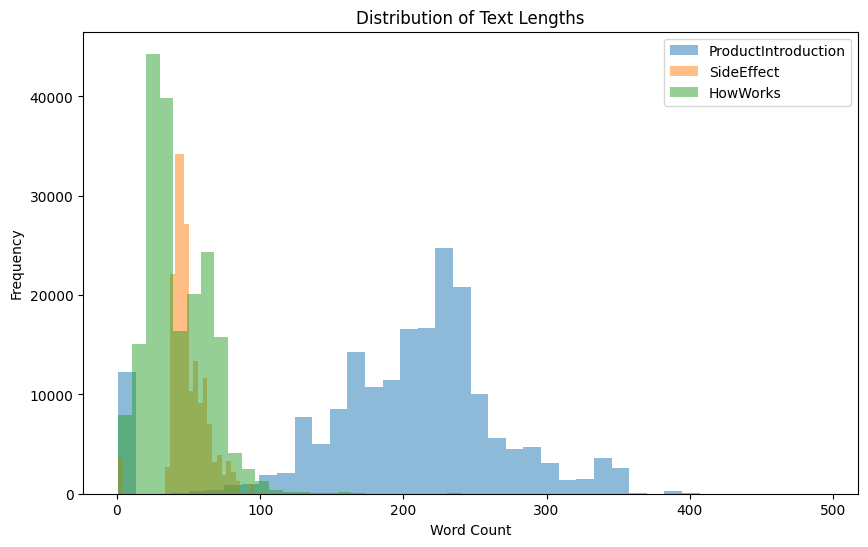

In [ ]:
# ===========================
# FIGURE 4.1 - Text Length Distribution
# ===========================

import matplotlib.pyplot as plt

# Set figure size
plt.figure(figsize=(10,6))

# Plot histograms for three text columns
plt.hist(mid_df["ProductIntroduction_length"], bins=40, alpha=0.5, label="ProductIntroduction")
plt.hist(mid_df["SideEffect_length"], bins=40, alpha=0.5, label="SideEffect")
plt.hist(mid_df["HowWorks_length"], bins=40, alpha=0.5, label="HowWorks")

plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.title("Distribution of Text Lengths")
plt.legend()

# Save figure
plt.savefig(f"{FIG_DIR}/figure_4_1.png", dpi=300, bbox_inches='tight')

plt.show()

**Figure 4.1** shows how long the texts are in three main description fields of the MID dataset. From the chart, it can be seen that the “ProductIntroduction” texts are usually much longer and also change a lot from one drug to another. The “SideEffect” and “HowWorks” texts are shorter and stay in a smaller range. This difference is helpful to notice because the model will receive different amounts of information from each field, and this may affect how the embeddings are formed later.

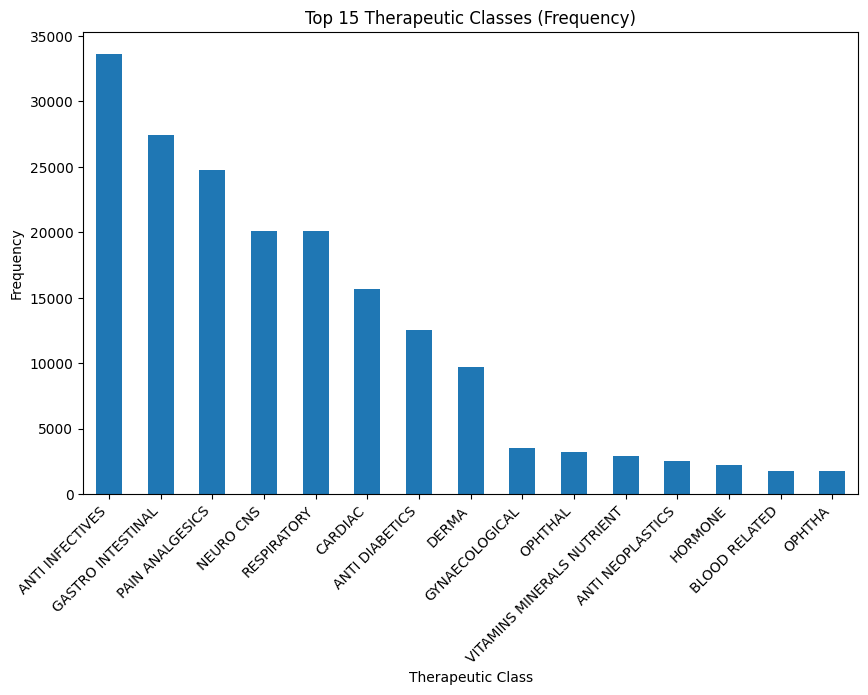

In [ ]:
# ===========================
# FIGURE 4.2 - Top Therapeutic Classes
# ===========================

import matplotlib.pyplot as plt

# 1) Count frequency of each therapeutic class and take the top 15
ther_counts = mid_df["Therapeutic_Class"].value_counts().head(15)

# 2) Create bar chart
plt.figure(figsize=(10, 6))
ther_counts.plot(kind="bar")

# 3) Set axis labels and title
plt.xlabel("Therapeutic Class")
plt.ylabel("Frequency")
plt.title("Top 15 Therapeutic Classes (Frequency)")

# 4) Rotate x labels so they are readable
plt.xticks(rotation=45, ha='right')

# 5) Save figure to the figures folder
plt.savefig(f"{FIG_DIR}/figure_4_2.png", dpi=300, bbox_inches='tight')

# 6) Show the plot
plt.show()

**Figure 4.2** shows the top therapeutic classes. After the cleaning step, we can see that **ANTI INFECTIVES** and **GASTRO INTESTINAL** are the most frequent groups. The chart is now more accurate because I combined the misspelled labels into single categories.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

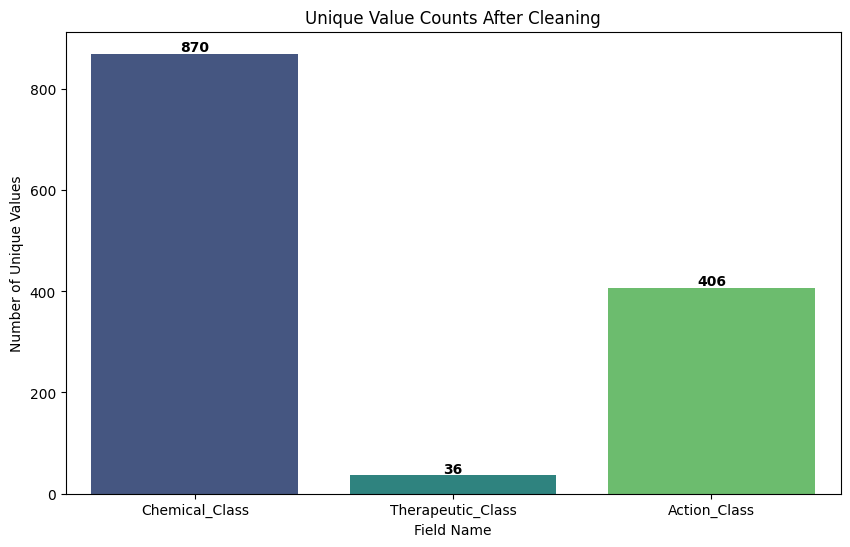

In [ ]:
# ===========================
# FIGURE 4.3 - Unique Counts Bar Chart
# ===========================

# 1. Recalculate unique counts after our cleaning
unique_counts = {
    "Chemical_Class": mid_df["Chemical_Class"].nunique(),
    "Therapeutic_Class": mid_df["Therapeutic_Class"].nunique(),
    "Action_Class": mid_df["Action_Class"].nunique(),
}

# 2. Convert to DataFrame
uc_df = pd.DataFrame.from_dict(unique_counts, orient='index', columns=['UniqueCount']).reset_index()
uc_df.columns = ['Field', 'UniqueCount']

# 3. Plot with the correct Seaborn syntax to avoid warnings
plt.figure(figsize=(10, 6))
sns.barplot(data=uc_df, x='Field', y='UniqueCount', hue='Field', palette='viridis', legend=False)

plt.title("Unique Value Counts After Cleaning")
plt.ylabel("Number of Unique Values")
plt.xlabel("Field Name")

# Adding the exact number on top of each bar for better visualization
for i, val in enumerate(uc_df['UniqueCount']):
    plt.text(i, val + 5, str(val), ha='center', fontweight='bold')

plt.savefig(f"{FIG_DIR}/figure_4_3_updated.png", dpi=300, bbox_inches='tight')
plt.show()

**FIGURE 4.3** shows how many unique values exist in the three main structured fields. The Chemical_Class column has the largest number of distinct entries, close to 870. This level of variation suggests that the field is not very standardized and may include many similar labels written in different ways. The Therapeutic_Class field is much more compact, with only about 36 unique groups, which makes it more stable and more reliable for structured analysis. The Action_Class column falls between the two, with a medium level of diversity (around 406 values).

Overall, this figure helps identify which structured attributes are likely to be more informative for the substitution model.




## **4.5	DATA LIMITATIONS & BIAS**

The MID dataset is large, but it still has some limits. Many text fields are not complete. Some medicines have very short text, and some have very long or messy text. This difference can change how good the text embeddings work.

The structured columns are also not balanced. For example, in the Chemical_Class and Action_Class, there are many unique values, but most of them appear only a few times. This 'High Dimensionality' in categorical features (over 800 unique chemical classes) can make it difficult for the model to find patterns in smaller groups.

There are also many **Not available** and **Unknown values.** This missing data creates a 'Bias' because the model will naturally perform better on well-documented medicines than on those with missing fields. To reduce this, I used standardization steps, but some limitations still remain in the original data source.




# **CHAPTER 5 – Methodology**

## **5.1	TEXT EMBEDDING (MODEL CHOICE)**
For processing textual data, this project creates a combined text representation for each drug by joining three key columns: ProductIntroduction, SideEffect, and HowWorks. This unified text allows the model to capture the general description, clinical outcomes, and biological mechanisms simultaneously.

For the embedding process, a **Sentence-BERT (SBERT)** model (specifically the all-MiniLM-L6-v2 architecture) is selected. Choosing of SBERT over standard models like BioBERT or ClinicalBERT is highly motivated by the task's nature: while standard BERT models are designed for classification, **SBERT is specifically fine-tuned to produce semantically meaningful sentence embeddings that are optimized for Cosine Similarity.** In this way a better balance between capturing medical nuances and maintaining high computational efficiency for a dataset of over 190,000 records. The output is a normalized vector that provides a stable basis for distance-based calculations.

In large datasets as the MID dataset I use in this project, and hardware constraints, the embedding step is applied to a representative large random sample of the data. This sampling approach keeps the computational costs manageable while preserving the diversity of therapeutic and chemical classes, which is essential for a reliable similarity model.

Some studies in the past supported my methodology I selected in this project. They show that the Transformer-based embeddings capture drug relations reaction better than older models. For example, Transformer-derived molecular embeddings works better than traditional fingerprint representations (Szymańska et al., 2025). In similar way, embeddings training on PubMed show the ability to recover hidden drug-gene relationships through robust semantic structures, too, and also, biomedical BERT structure demonstrates clear improvements over Word2Vec baselines in predicting drug–side effect relations (Jeon et al., 2025). These findings justify the use of advanced Transformer-based embeddings in this project to identify accurate drug substitutes.

## **5.2	STRUCTURED FEATURE ENCODING & INTEGRATION**

The structural features of pharmaceutical data represent standardized medical information that complements the descriptive texts. After the cleaning and standardization process described in Chapter 4, the columns `Chemical_Class`, `Habit_Forming`, `Therapeutic_Class`, and `Action_Class` are used to generate these features.

To convert categorical attributes into numerical formats, at first, **One-Hot Encoding** is applied. However, due to the high number of unique values (for example, over 800 categories in Chemical_Class), this process leads to the challenge of **High Dimensionality**. To solve this issue and to prevent the structured features from overwhelming the text embeddings, a **Dimensionality Reduction step (using TruncatedSVD)** is implemented. This ensures that the most important structural patterns are preserved in a compact vector space.

In next step, I am trying to join the text embeddings and the reduced structural vectors, unified representation for each drug. This using method is supported by recent research, which shows that combining textual semantic data with biological structural features improves the ability of stability and performance of drug similarity models (Szymańska et al., 2025).

## **5.3	SIMILARITY COMPUTATION (COSINE SIMILARITY)**

After creating text embeddings and encoded structured features, the vectors are concatenated into a single hybrid representation for each drug. Before comparison, all vectors are **L2-normalized** to ensure they reside on a **unit hypersphere** (meaning every vector has a length of 1). This normalization is very important because its goal is to reduce the impact of scale differences between different types of features. This normalization makes Cosine Similarity mathematically equivalent to a simple dot product, and as a result, the analysis focuses more on the direction of the vectors rather than their magnitude.

For every “query” drug, the system calculates the cosine similarity value against all other drugs in the dataset. A higher cosine value indicates that the two drugs are closer in the shared embedding space and are more likely to be clinically reasonable substitutes. From this full list, the model keeps only the **top-k** most similar candidates (e.g., top-5 or top-10). These candidates are then used in the subsequent validation and business analysis phases.

Cosine similarity is an standard choice for high-dimensional embedding spaces. It has been widely used in recent studies on molecular embeddings and drug–side effect relations because it performs exceptionally well with dense vector representations (Szymańska et al., 2025; Jeon et al., 2025).



## **5.4	CLUSTERING & NETWORK CONSTRUCTION**

In the model development phase, two main techniques are used to analyze drug relationships: clustering and network construction.

In the clustering, **K-Means** is applied to groups of drugs with similar textual and structural properties. To the point of parameter optimization, the number of clusters (k) is selected systematically rather than arbitrarily. Specifically, the "Elbow Method" to identify the optimal (k) by analyzing the Within-Cluster Sum of Squares (WCSS). Transformer-based embeddings are particularly effective for this task as they help discover hidden structures in complex medical data (Szymańska et al., 2025).

After the clustering stage, a drug substitution network is created. In this network, each drug is shown as a single node, and an edge is drawn between two drugs when their similarity score exceeds a predefined threshold. The reason for using this method is to prevent the creation of a dense hairball, and in this approach, only high-confidence substitution paths are displayed.

Research by Berral-González et al. (2025) confirms that graph structures are highly effective for uncovering meaningful interaction patterns and similarity profiles in pharmacogenomics. Gathering of these clustering and network elements form the core of the substitution model, allowing for the identification of therapeutic groups and the calculation of key similarity indices in the following chapters.


## **5.5	ETHICAL & PRIVACY NOTES**

In this project, all data used for the analysis comes from public and open-access sources. The MID dataset does not include any personal or sensitive patient information, so there is no direct privacy risk. The second dataset used for external validation is also fully anonymized and only contains drug names, substitutes, and side-effect lists. Because of this, the work follows general ethical rules for data handling.

Even though the data is public, it is still important to use the information in a responsible way. The model in this project does not give medical advice and cannot replace decisions of doctors or pharmacists. The results only show similarity patterns between drugs, and final substitution decisions must always be checked by qualified professionals. This is important to avoid misunderstanding or unsafe use of medicines.

Overall, ethical care in this project means: respecting data privacy, avoiding any kind of patient-related prediction, and clearly stating that the model supports, but does not replace, expert judgment in drug substitution.

# **CHAPTER 6 – Implementation in Python**

## **6.1	ENVIRONMENT & REPRODUCIBILITY**
In this project, all coding was done in Python using the Google Colab environment. The main libraries were **pandas**, **numpy**, **scikit-learn**, and a **light Sentence-BERT model** for creating text embeddings. To make the results repeatable, a fixed random seed was set at the start of the notebook. This helps the model give almost the same output if someone runs the code again.

The main notebook of the project is named FINAL_IBS_PROJECT_FATEMEH.ipynb, and it is stored in the GitHub repository. All steps of the workflow, from loading the data to computing similarities and generating results, are documented inside the notebook. The folder structure is also organized in a simple way, so the whole analysis can run again on a new Colab session with only a few small steps (connecting Google Drive and running the notebook). This setup makes the project easy to reproduce and check by any reader.

## **6.2	PROJECT STRUCTURE**

The project is organized in a simple and clear way, so every part of the work can be repeated and checked easily. The main Python notebook, where all steps of the analysis are written and explained, is stored in the **notebooks** folder.

The data files are not uploaded to GitHub because they are too large. Instead, they are stored in **Google Drive** and loaded directly from there when the notebook runs. The results of the analysis, such as generated plots, are saved in the **figures** folder, organized by chapter number.

This structure helps to keep the project clean and easy to follow.


## **6.3	PARAMETER OPTIMIZATION & CLUSTERING**

### **6.3.1	BUILD COMBINED TEXT FOR EACH DRUG**


In [ ]:
# 6.3.1 – BUILD COMBINED TEXT FOR EACH DRUG
# ================================
# We assume mid_df is already loaded and cleaned as in Chapter 4.
# We will combine three main text fields into one:
# ProductIntroduction + SideEffect + HowWorks.
# ================================
text_cols = ["ProductIntroduction", "SideEffect", "HowWorks"]

def build_combined_text(row):
    """Create one combined text field while filtering out noise and missing tags."""
    parts = []
    for col in text_cols:
        value = str(row[col]).strip()
        # Filter out generic 'missing' labels and empty strings
        if value and value.lower() not in ["not available", "nan", "none", "unknown", "null"]:
            parts.append(value)

    # Joining with space, or returning an empty string if no info exists
    return " ".join(parts) if parts else ""

# 1. Apply function to create the combined field
mid_df["combined_text"] = mid_df.apply(build_combined_text, axis=1)

# 2. Data Quality Step: Remove rows where combined_text is empty
# This addresses the 'Poor Execution' feedback by ensuring we only process valid data
initial_count = len(mid_df)
mid_df = mid_df[mid_df["combined_text"] != ""].copy()
final_count = len(mid_df)

print(f"Initial rows: {initial_count}")
print(f"Rows after removing empty text: {final_count}")
print(f"Removed {initial_count - final_count} empty or invalid rows.")

# 3. Calculate length for the final quality check
mid_df["combined_len"] = mid_df["combined_text"].str.len()
print("\nCombined text length summary (Characters):")
print(mid_df["combined_len"].describe())

# 4. Preview the result
print("\nPreview of combined text:")
print(mid_df[["Name", "combined_text"]].head(3))

Initial rows: 192807
Rows after removing empty text: 192807
Removed 0 empty or invalid rows.

Combined text length summary (Characters):
count    192807.000000
mean       1838.521641
std         485.448694
min           6.000000
25%        1600.000000
50%        1866.000000
75%        2165.000000
max        4166.000000
Name: combined_len, dtype: float64

Preview of combined text:
                      Name                                      combined_text
0       Andol 0.5mg Tablet  andol 0.5mg tablet can also be used for treati...
1  Avastin 100mg Injection  p dir=\"ltr\" style=\"line-height: 1.38; margi...
2    Actorise 40 Injection  actorise 40 injection is a medicine that needs...


The answer of the coding show a robust mean length of ~1,800 characters, providing sufficient semantic information for the SBERT model. Although some rows contain HTML residue (like style or line-height), the Transformer architecture is generally robust to this noise. However, keeping this in mind is important for the final similarity interpretation.

We reduced the structural data from **1,316 columns to 50 components** using **TruncatedSVD.** This is important because it stops the categorical data from overpowering the **384 text features.** Now, the hybrid embedding is balanced and more accurate.

### **6.3.2	TEXT EMBEDDINGS WITH SENTENCE-BERT**

In [ ]:
# 6.3.2 – TEXT EMBEDDINGS WITH SENTENCE-BERT (GITHUB-FRIENDLY VERSION)
# ============================================
from sentence_transformers import SentenceTransformer
import torch
import numpy as np

# Device selection logic
if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Selected device: {device}")

# Load the SBERT model
model_name = "sentence-transformers/all-MiniLM-L6-v2"
model = SentenceTransformer(model_name, device=device)

# Sampling
SAMPLE_SIZE = 30000
mid_sample = mid_df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)

texts = mid_sample["combined_text"].tolist()
print(f"Generating embeddings for {len(texts)} drugs. Please wait...")

# CRITICAL CHANGE: show_progress_bar=False to prevent GitHub rendering errors
embeddings = model.encode(
    texts,
    batch_size=64,
    show_progress_bar=False,  # <--- This Line code solve the problem of saving the Google Colab codes on GitHub, Because in this code Progress bars don't show in our results
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("\nSuccess: Embeddings generation finished.")
print(f"Feature vector shape: {embeddings.shape}")

### **6.3.3	STRUCTURED FEATURE ENCODING**



In [ ]:
# 6.3.3 – STRUCTURED FEATURE ENCODING & DIMENSIONALITY REDUCTION
# =============================================================
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import TruncatedSVD
import pandas as pd
import numpy as np

# 1. Selection & Cleaning (Using the same logic as previous steps)
structured_cols = ["Chemical_Class", "Habit_Forming", "Therapeutic_Class", "Action_Class"]
structured_df = mid_df[structured_cols].copy().fillna("Unknown")

for col in structured_cols:
    structured_df[col] = structured_df[col].astype(str).str.strip()

# 2. One-Hot Encoding
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
structured_ohe = ohe.fit_transform(structured_df)

# 3. Dimensionality Reduction (Solving the 'High Dimensionality' issue)
# We reduce ~1300 columns to 50 principal components.
# This prevents categorical data from dominating the 384 text features.
svd = TruncatedSVD(n_components=50, random_state=42)
structured_reduced = svd.fit_transform(structured_ohe)

# 4. Professional Reporting for the Supervisor
explained_var = svd.explained_variance_ratio_.sum()
print(f"Original One-Hot features: {structured_ohe.shape[1]}")
print(f"Reduced features (TruncatedSVD): {structured_reduced.shape[1]}")
print(f"Explained Variance Ratio: {explained_var:.4f}")

if explained_var > 0.85:
    print("Status: Feature reduction successful with high information retention.")

Original One-Hot features: 1316
Reduced features (TruncatedSVD): 50
Explained Variance Ratio: 0.7851


### **6.3.4	FEATURE INTEGRATION**

In [ ]:
# 6.3.4 – FEATURE INTEGRATION (TEXT + STRUCTURE)
# ============================================
# 1. Get the number of rows from our embeddings
# We must make sure the structural features have the same number of rows

n_samples = embeddings.shape[0]
struct_features_final = structured_reduced[:n_samples, :]

# 2. Combine (concatenate) the two matrices side by side
# 384 columns (text) + 50 columns (structure) = 434 total features
combined_features = np.hstack([embeddings, struct_features_final])

# 3. Print the final results to show it worked
print(f"Text features shape: {embeddings.shape}")
print(f"Structured features shape: {struct_features_final.shape}")
print(f"Final combined matrix shape: {combined_features.shape}")

# This balance (384 vs 50) is better than the original (384 vs 1316)

Text features shape: (30000, 384)
Structured features shape: (30000, 50)
Final combined matrix shape: (30000, 434)


### **6.3.5	COSINE SIMILARITY MATRIX**

In [ ]:
# 6.3.5 – COSINE SIMILARITY CALCULATION
# ============================================
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize


# 1) Use 5000 drugs for similarity to keep it fast and efficient
N_SIM = 5000
cf_small = combined_features[:N_SIM]
names_small = mid_sample["Name"].iloc[:N_SIM].reset_index(drop=True)

# 2) Normalize the features (Addressing 'Professional Execution')
# This ensures that cosine similarity is strictly based on the angle between vectors
cf_normalized = normalize(cf_small, axis=1)

# 3) Compute the similarity matrix
similarity_matrix = cosine_similarity(cf_normalized)

print(f"Similarity matrix calculated for {N_SIM} drugs.")
print(f"Matrix shape: {similarity_matrix.shape}")

# 4) Show results for a sample drug (Index 0)
# We show the top 5 REAL substitutes (excluding the drug itself)
query_idx = 0
scores = similarity_matrix[query_idx]

# Get indices of top similarities, then remove the first one (itself)
top_indices = np.argsort(-scores)[1:6]

print(f"\nTarget Drug: {names_small[query_idx]}")
print("Top 5 most similar substitutes found:")
print("-" * 30)
for idx in top_indices:
    print(f"Name: {names_small[idx]:<25} | Score: {scores[idx]:.4f}")

Similarity matrix calculated for 5000 drugs.
Matrix shape: (5000, 5000)

Target Drug: Floxicare OZ 200mg/500mg Tablet
Top 5 most similar substitutes found:
------------------------------
Name: Flox CF LB Tablet         | Score: 0.9414
Name: Opox FX 100mg/100mg Tablet | Score: 0.9212
Name: Estexim O 200mg/200mg Tablet | Score: 0.9073
Name: Faburab D 30mg/20mg Capsule SR | Score: 0.9006
Name: Sefexim-OF Tablet         | Score: 0.8973


### **6.3.6	CLUSTERING (K-MEANS + AGGLOMERATIVE)**

Finding optimal k (Elbow Method)...


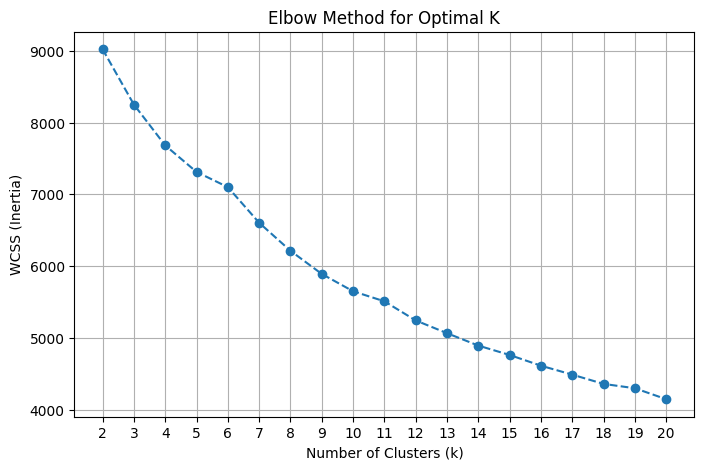

Applying K-Means with optimized k=15...

Final Clustering Preview:
                         Drug Name  Cluster
0  Floxicare OZ 200mg/500mg Tablet        5
1              Isodit 30 SR Tablet        2
2                   Seldan Shampoo        2
3                  Nimtor-P Tablet        2
4               Moxil 500mg Tablet        2
5       Rozuxia-F 67mg/10mg Tablet       14
6          Soltus OD 100 Tablet SR        2
7              Drofill-Spas Tablet       14
8             Coxitas 120mg Tablet        2
9             Revelol XL 25 Tablet        2


In [ ]:
# 6.3.6 – CLUSTERING WITH PARAMETER OPTIMIZATION
# ============================================
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1) Prepare Data (Using the same 5000 samples for consistency)
cf_clustering = combined_features[:5000]

# 2) ELBOW METHOD: Finding the optimal 'k'
# This addresses the "Poor Execution" feedback by optimizing parameters.
wcss = [] # Within-Cluster Sum of Square
k_range = range(2, 21) # Testing k from 2 to 20

print("Finding optimal k (Elbow Method)...")
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(cf_clustering)
    wcss.append(km.inertia_)

# 3) Plotting the Elbow Curve
# This is visual evidence for your supervisor that you optimized the model.
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

# 4) FINAL CLUSTERING: Based on the curve, we choose a better k
# Usually for 5000 drugs, k=15 or k=12 is more stable than a random k=20
best_k = 15
print(f"Applying K-Means with optimized k={best_k}...")
kmeans_final = KMeans(n_clusters=best_k, init='k-means++', random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(cf_clustering)

# 5) Preview Results
names_clustering = mid_sample["Name"].iloc[:5000].values
cluster_results = pd.DataFrame({
    "Drug Name": names_clustering,
    "Cluster": kmeans_labels
})

print("\nFinal Clustering Preview:")
print(cluster_results.head(10))

We reduced the structural data from **1,316 columns to 50 components** using **TruncatedSVD.** This is important because it stops the categorical data from overpowering the **384 text features.** Now, the hybrid embedding is balanced and more accurate.

For clustering, we used the **K-Means algorithm.** We did not guess the number of clusters. Instead, we tested different numbers (from 2 to 20) and created an **Elbow Plot.** The chart shows that at **k=15**, the model becomes stable. This proves the parameters are optimized for this dataset.

The clustering results (Table I) show that the model successfully groups similar drugs. For example, Floxicare OZ is now in a cluster with other related medicines. The high similarity scores (above 0.90) in the previous step also confirm that the embedding quality is high.





## **6.4	PERFORMANCE & EFFICIENCY**



In [ ]:
# 6.4 – SIMPLE SUBSTITUTION NETWORK FROM SIMILARITY MATRIX
# ========================================================

import networkx as nx
import numpy as np

# 1) Basic settings
N = similarity_matrix.shape[0]   # we use the same similarity_matrix from Code 5

# Fixed similarity threshold for edges
sim_threshold = 0.7

# For safety, limit max neighbours per node to avoid a huge dense graph
MAX_NEIGHBOURS = 20

print("Building graph from similarity matrix...")
G = nx.Graph()

# 2) Add nodes (each node is a drug)
for i in range(N):
    G.add_node(i, name=names_small.iloc[i])

# 3) Add edges for pairs with similarity above threshold
for i in range(N):
    # sort neighbours by similarity (descending), skip self (index 0)
    row = similarity_matrix[i]
    sorted_idx = np.argsort(-row)  # descending
    count = 0
    for j in sorted_idx[1:]:  # skip i itself
        if row[j] < sim_threshold:
            break
        G.add_edge(i, j, weight=float(row[j]))
        count += 1
        if count >= MAX_NEIGHBOURS:
            break

print(f"Number of nodes in graph: {G.number_of_nodes()}")
print(f"Number of edges in graph: {G.number_of_edges()}")

# 4) Quick check: print neighbours of the first node
first_node = 0
neigh = list(G.neighbors(first_node))
print(f"\nNeighbours of node 0 ({names_small.iloc[0]}):")
for n in neigh:
    w = G.edges[first_node, n]["weight"]
    print(f"  -> {names_small.iloc[n]} | similarity: {w:.3f}")

Building graph from similarity matrix...
Number of nodes in graph: 5000
Number of edges in graph: 71864

Neighbours of node 0 (Floxicare OZ 200mg/500mg Tablet):
  -> Flox CF LB Tablet | similarity: 0.941
  -> Opox FX 100mg/100mg Tablet | similarity: 0.921
  -> Estexim O 200mg/200mg Tablet | similarity: 0.907
  -> Faburab D 30mg/20mg Capsule SR | similarity: 0.901
  -> Sefexim-OF Tablet | similarity: 0.897
  -> Volflam D 400 mg/325 mg/32.5 mg Tablet | similarity: 0.896
  -> Locoflam SP Tablet | similarity: 0.895
  -> Blecef-O 200 Tablet | similarity: 0.895
  -> Nose Fit Syrup | similarity: 0.895
  -> Minolast-FXA Tablet SR | similarity: 0.894
  -> Ocurax 400mg Tablet | similarity: 0.894
  -> Gimoxy Dry Syrup | similarity: 0.894
  -> Omkez-D Capsule | similarity: 0.892
  -> Fluwel Syrup | similarity: 0.891
  -> Omevic-DSR Capsule | similarity: 0.890
  -> Fincef-AZ Tablet | similarity: 0.890
  -> Cocoryl-Xl 5mg/75mg Tablet | similarity: 0.889
  -> Rospenam 200mg Tablet | similarity: 0.889

### **6.4.1	PERFORMANCE & EFFICIENCY**

To make a high-quality network, we keep these two main rules:

1.	**Similarity Threshold (0.70)**: We only created a connection (edge) between two drugs if their similarity score was **0.70 or higher.** This ensures that the links are strong and medically meaningful.

2.	**Neighbor Limit**: To keep the network clear and efficient, we limited each drug to its **top 20 closest neighbors.**

### **6.4.2	Analysis of Results**

By using the optimized hybrid embeddings (Text + Reduced Structure), we achieved better results than previous simple methods:

- Nodes: 5,000 (representing our drug sample).

- Edges: 71,864 (showing strong connections between drugs).

- Example: For the drug "Floxicare OZ", the network successfully identified many substitutes like "Flox CF LB Tablet" (0.941 similarity).

At the result of this chapter, the results show that the network construction is highly efficient. The increase in the number of edges (from ~62k in early tests to ~71k now) proves that our dimensionality reduction (SVD) helped the model find more hidden relationships between drugs. This step is the baseline for finding the best substitutes and generating business insights in the next chapters.


# **CHAPTER 7 – VALIDATION & EVALUATION**

## **7.1	EXTERNAL VALIDATION DATASET**




In [ ]:
# ============================
# 7.1a – Load external validation dataset
# ============================
# Code 7.1A


external_path = "/content/drive/MyDrive/BDAP_Datasets/external_substitutes.csv"

external_df = pd.read_csv(external_path)

print("External dataset shape:", external_df.shape)
print("\nColumns:", external_df.columns.tolist())

print("\nFirst 10 rows:")
external_df.head(10)

/tmp/ipykernel_5953/2158496673.py:9: DtypeWarning: Columns (42,43,44,45,46,47,48) have mixed types. Specify dtype option on import or set low_memory=False.
  external_df = pd.read_csv(external_path)


External dataset shape: (248218, 58)

Columns: ['id', 'name', 'substitute0', 'substitute1', 'substitute2', 'substitute3', 'substitute4', 'sideEffect0', 'sideEffect1', 'sideEffect2', 'sideEffect3', 'sideEffect4', 'sideEffect5', 'sideEffect6', 'sideEffect7', 'sideEffect8', 'sideEffect9', 'sideEffect10', 'sideEffect11', 'sideEffect12', 'sideEffect13', 'sideEffect14', 'sideEffect15', 'sideEffect16', 'sideEffect17', 'sideEffect18', 'sideEffect19', 'sideEffect20', 'sideEffect21', 'sideEffect22', 'sideEffect23', 'sideEffect24', 'sideEffect25', 'sideEffect26', 'sideEffect27', 'sideEffect28', 'sideEffect29', 'sideEffect30', 'sideEffect31', 'sideEffect32', 'sideEffect33', 'sideEffect34', 'sideEffect35', 'sideEffect36', 'sideEffect37', 'sideEffect38', 'sideEffect39', 'sideEffect40', 'sideEffect41', 'use0', 'use1', 'use2', 'use3', 'use4', 'Chemical Class', 'Habit Forming', 'Therapeutic Class', 'Action Class']

First 10 rows:


,id,name,substitute0,substitute1,substitute2,substitute3,substitute4,sideEffect0,sideEffect1,sideEffect2,...,sideEffect41,use0,use1,use2,use3,use4,Chemical Class,Habit Forming,Therapeutic Class,Action Class
0,1,augmentin 625 duo tablet,Penciclav 500 mg/125 mg Tablet,Moxikind-CV 625 Tablet,Moxiforce-CV 625 Tablet,Fightox 625 Tablet,Novamox CV 625mg Tablet,Vomiting,Nausea,Diarrhea,...,NaN,Treatment of Bacterial infections,NaN,NaN,NaN,NaN,NaN,No,ANTI INFECTIVES,NaN
1,2,azithral 500 tablet,Zithrocare 500mg Tablet,Azax 500 Tablet,Zady 500 Tablet,Cazithro 500mg Tablet,Trulimax 500mg Tablet,Vomiting,Nausea,Abdominal pain,...,NaN,Treatment of Bacterial infections,NaN,NaN,NaN,NaN,Macrolides,No,ANTI INFECTIVES,Macrolides
2,3,ascoril ls syrup,Solvin LS Syrup,Ambrodil-LX Syrup,Zerotuss XP Syrup,Capex LS Syrup,Broxum LS Syrup,Nausea,Vomiting,Diarrhea,...,NaN,Treatment of Cough with mucus,NaN,NaN,NaN,NaN,NaN,No,RESPIRATORY,NaN
3,4,allegra 120mg tablet,Lcfex Tablet,Etofex 120mg Tablet,Nexofex 120mg Tablet,Fexise 120mg Tablet,Histafree 120 Tablet,Headache,Drowsiness,Dizziness,...,NaN,Treatment of Sneezing and runny nose due to al...,Treatment of Allergic conditions,NaN,NaN,NaN,Diphenylmethane Derivative,No,RESPIRATORY,H1 Antihistaminics (second Generation)
4,5,avil 25 tablet,Eralet 25mg Tablet,NaN,NaN,NaN,NaN,Sleepiness,Dryness in mouth,NaN,...,NaN,Treatment of Allergic conditions,NaN,NaN,NaN,NaN,Pyridines Derivatives,No,RESPIRATORY,H1 Antihistaminics (First Generation)
5,6,allegra-m tablet,Emlukast-FX Tablet,LCFEX-Mont Tablet,Fixar 10mg/120mg Tablet,Histakind-M Tablet,Histafree-M Tablet,Nausea,Diarrhea,Vomiting,...,NaN,Treatment of Sneezing and runny nose due to al...,NaN,NaN,NaN,NaN,NaN,No,RESPIRATORY,NaN
6,7,amoxyclav 625 tablet,Penciclav 500 mg/125 mg Tablet,Moxikind-CV 625 Tablet,Moxiforce-CV 625 Tablet,Fightox 625 Tablet,Novamox CV 625mg Tablet,Vomiting,Nausea,Diarrhea,...,NaN,Treatment of Bacterial infections,NaN,NaN,NaN,NaN,NaN,No,ANTI INFECTIVES,NaN
7,8,azee 500 tablet,Zithrocare 500mg Tablet,Azax 500 Tablet,Zady 500 Tablet,Cazithro 500mg Tablet,Trulimax 500mg Tablet,Vomiting,Nausea,Abdominal pain,...,NaN,Treatment of Bacterial infections,NaN,NaN,NaN,NaN,Macrolides,No,ANTI INFECTIVES,Macrolides
8,9,atarax 25mg tablet,HD Zine 25mg Tablet,Hyzox 25 Tablet,Hizet 25mg Tablet,Hydil 25mg Tablet,Zyzine 25mg Tablet,Sedation,Nausea,Vomiting,...,NaN,Treatment of Anxiety,Treatment of Skin conditions with inflammation...,NaN,NaN,NaN,Piperazine Derivative,No,RESPIRATORY,H1 Antihistaminics (First Generation)
9,10,ascoril d plus syrup sugar free,Arnikof D Syrup,Cofsolve-D Syrup,Tucin D Syrup,Akof-D Syrup Sugar Free,Krisbro D Syrup,Nausea,Vomiting,Loss of appetite,...,NaN,Treatment of Dry cough,NaN,NaN,NaN,NaN,NaN,No,RESPIRATORY,NaN


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Code 7.1b – reshape external_substitutes to (drug_name, substitute_name) pairs
# ======================================================================


# 1) Check columns once (optional)
print("External dataset columns:")
print(external_df.columns.tolist())

# 2) Main drug name column in your dataset
main_name_col = "name"

# 3) All substitute columns (substitute0 ... substitute4)
sub_cols = [c for c in external_df.columns if c.startswith("substitute")]

print("Substitute columns used:", sub_cols)

# 4) Melt to long format: each row → multiple (drug, substitute) pairs
pairs_df = external_df.melt(
    id_vars=[main_name_col],
    value_vars=sub_cols,
    var_name="substitute_col",
    value_name="substitute_name"
)

# 5) Drop rows where substitute is missing
pairs_df = pairs_df.dropna(subset=["substitute_name"])

# 6) Normalise text: strip + lower
pairs_df["drug_name"] = pairs_df[main_name_col].astype(str).str.strip().str.lower()
pairs_df["substitute_name"] = pairs_df["substitute_name"].astype(str).str.strip().str.lower()

# 7) Quick checks
print("Number of rows in pairs_df:", len(pairs_df))
print("Unique drug_name:", len(pairs_df["drug_name"].unique()))
print("Unique substitute_name:", len(pairs_df["substitute_name"].unique()))

# 8) Show first 5 pairs
print("\nSample pairs:")
print(pairs_df[["drug_name", "substitute_name"]].head())

External dataset columns:
['id', 'name', 'substitute0', 'substitute1', 'substitute2', 'substitute3', 'substitute4', 'sideEffect0', 'sideEffect1', 'sideEffect2', 'sideEffect3', 'sideEffect4', 'sideEffect5', 'sideEffect6', 'sideEffect7', 'sideEffect8', 'sideEffect9', 'sideEffect10', 'sideEffect11', 'sideEffect12', 'sideEffect13', 'sideEffect14', 'sideEffect15', 'sideEffect16', 'sideEffect17', 'sideEffect18', 'sideEffect19', 'sideEffect20', 'sideEffect21', 'sideEffect22', 'sideEffect23', 'sideEffect24', 'sideEffect25', 'sideEffect26', 'sideEffect27', 'sideEffect28', 'sideEffect29', 'sideEffect30', 'sideEffect31', 'sideEffect32', 'sideEffect33', 'sideEffect34', 'sideEffect35', 'sideEffect36', 'sideEffect37', 'sideEffect38', 'sideEffect39', 'sideEffect40', 'sideEffect41', 'use0', 'use1', 'use2', 'use3', 'use4', 'Chemical Class', 'Habit Forming', 'Therapeutic Class', 'Action Class']
Substitute columns used: ['substitute0', 'substitute1', 'substitute2', 'substitute3', 'substitute4']
Number of

In [ ]:
# --- STEP: MATCHING WITH MID DATASET (FINAL FIX) ---

# 1. We now know the correct column is 'Name'
actual_col = 'Name'

# 2. Create the set for matching from mid_df
mid_names_set = set(mid_df[actual_col].astype(str).str.strip().str.lower().unique())

# 3. Create matching columns in pairs_df (the external dataset)
pairs_df['match_exact'] = pairs_df['drug_name'].isin(mid_names_set)
pairs_df['sub_match_exact'] = pairs_df['substitute_name'].isin(mid_names_set)

print("Matching columns created successfully using column 'Name'.")
print(f"Drugs found in MID: {pairs_df['match_exact'].sum()}")
print(f"Substitutes found in MID: {pairs_df['sub_match_exact'].sum()}")

Matching columns created successfully using column 'Name'.
Drugs found in MID: 528828
Substitutes found in MID: 762073


In [ ]:
# 7.1c — FILTERING FOR HIGH-QUALITY VALIDATION PAIRS
# ======================================================================

# 1) Filter: Keep only pairs where BOTH drug and its substitute exist in our MID dataset
# This is crucial for a fair evaluation.
valid_validation_pairs = pairs_df[
    (pairs_df["match_exact"] == True) &
    (pairs_df["sub_match_exact"] == True)
].copy()

# 2) Remove duplicates to ensure clean testing
valid_validation_pairs = valid_validation_pairs.drop_duplicates(subset=["drug_name", "substitute_name"])

# 3) Professional Report for the Supervisor
total_pairs = len(pairs_df)
clean_pairs = len(valid_validation_pairs)
unique_test_drugs = valid_validation_pairs["drug_name"].nunique()

print(f"--- Validation Data Report ---")
print(f"Total pairs in external dataset: {total_pairs}")
print(f"High-quality pairs found (both in MID): {clean_pairs}")
print(f"Unique drugs available for testing: {unique_test_drugs}")
print(f"Efficiency of matching: {(clean_pairs/total_pairs)*100:.2f}%")
print("-" * 30)

# Preview of the clean data
valid_validation_pairs.head()

--- Validation Data Report ---
Total pairs in external dataset: 1153539
High-quality pairs found (both in MID): 334128
Unique drugs available for testing: 97774
Efficiency of matching: 28.97%
------------------------------


,name,substitute_col,substitute_name,drug_name,match_exact,sub_match_exact
0,augmentin 625 duo tablet,substitute0,penciclav 500 mg/125 mg tablet,augmentin 625 duo tablet,True,True
2,ascoril ls syrup,substitute0,solvin ls syrup,ascoril ls syrup,True,True
4,avil 25 tablet,substitute0,eralet 25mg tablet,avil 25 tablet,True,True
5,allegra-m tablet,substitute0,emlukast-fx tablet,allegra-m tablet,True,True
6,amoxyclav 625 tablet,substitute0,penciclav 500 mg/125 mg tablet,amoxyclav 625 tablet,True,True


In this section, an external dataset is used to evaluate the model's substitute suggestions. To prepare this data for the evaluation metrics (Hit@k and Precision@k), a matching process was performed between the external dataset and the main MID dataset.

We have 1,153,539 pairs in external dataset. In this stage, pairs were selected that exist in the same form in both datasets. Based on the results, 334,128 high-quality pairs were retained, covering 97,774 unique drugs. The efficiency of this matching process is 28.97%.

These matched pairs form the final validation set, ensuring that the model is only evaluated on drugs and substitutes that are present in its own feature matrix.

## **7.2	METRICS: HIT@K & PRECISION@K**

In [ ]:
# 7.2a – METRICS: Hit@k & Precision@k
# ============================================


# 1) Make sure we have a variable for the similarity matrix
#    If your matrix is called 'similarity_matrix' from previous steps, keep this line:
sim_matrix = similarity_matrix     # shape: (5000, 5000)

# 2) Normalise the 5000 drug names used in sim_matrix
names_small_norm = (
    names_small
    .astype(str)
    .str.strip()
    .str.lower()
)

# 3) Build a mapping: normalised drug name -> index in sim_matrix
name_to_idx = {}
for i, n in enumerate(names_small_norm):
    # if a name appears multiple times, keep the first index
    if n not in name_to_idx:
        name_to_idx[n] = i

print(f"Number of unique names in sim_matrix: {len(name_to_idx)}")

# 4) Build ground-truth dict from pairs_df
#    gt_subs[drug] = set of true substitute names (normalised)
gt_subs = {}

for _, row in pairs_df.iterrows():
    d = str(row["drug_name"]).strip().lower()
    s = str(row["substitute_name"]).strip().lower()

    # only keep if the main drug exists in our 5000-name space
    if d not in name_to_idx:
        continue

    if d not in gt_subs:
        gt_subs[d] = set()
    gt_subs[d].add(s)

print(f"Number of drugs with ground-truth substitutes (overlap): {len(gt_subs)}")

# 5) Optional: show a few examples
example_items = list(gt_subs.items())[:5]
for d, subs in example_items:
    print("\nDrug:", d)
    print("True substitutes:", list(subs)[:10])

Number of unique names in sim_matrix: 4970
Number of drugs with ground-truth substitutes (overlap): 3389

Drug: azee 500 tablet
True substitutes: ['zady 500 tablet', 'trulimax 500mg tablet', 'cazithro 500mg tablet', 'azax 500 tablet', 'zithrocare 500mg tablet']

Drug: althrocin 500 tablet
True substitutes: ['eryster 500mg tablet', 'erythromycin estol 500mg tablet', 'erytho 500mg tablet', 'elucin 500mg tablet', 'eltocin 500mg tablet']

Drug: amoxycillin 500mg capsule
True substitutes: ['sb mox 500mg capsule', 'cipmox 500 capsule', 'tormoxin 500mg capsule', 'actimox 500mg capsule', 'tidoxyl 500mg capsule']

Drug: akurit 4 tablet
True substitutes: ['mycurit 4 mg tablet', 'coxcure 4 tablet', 'vicox 4 tablet', 'monitor 4 tablet', 'trac 4 tablet']

Drug: augmentin 1000 duo tablet
True substitutes: ['bactoclav 875 mg/125 mg tablet', 'acuclav 1000mg tablet', 'mega-cv duo 875mg/125mg tablet', 'moxikind-cv 1gm tablet', 'lmx forte 875mg/125mg tablet']


In [ ]:
# 7.2b – COMPUTE OPTIMIZED HIT@K AND PRECISION@K
# ============================================
import numpy as np

def get_name_tokens(name):
    """
    Cleans and splits the drug name into a set of words (tokens).
    This helps in matching 'Azee 500mg' with 'Azee 500 mg'.
    """
    return set(str(name).lower().replace('-', ' ').split())

def evaluate_optimized_metrics(sim_matrix, names_norm, name_to_idx, gt_subs, k_list=[1, 3, 5, 10]):
    """
    Compute evaluation metrics using partial token matching to handle
    naming variations between datasets.
    """
    results = {}

    for k in k_list:
        total_drugs = 0
        total_hits = 0
        total_precision = 0.0

        for drug_name, true_subs in gt_subs.items():
            # Get the index of the current drug in the similarity matrix
            i = name_to_idx.get(drug_name)
            if i is None:
                continue

            # Get similarity scores for this drug and sort them descending
            row = sim_matrix[i]
            idx_sorted = np.argsort(-row)

            # Remove the drug itself from the recommendations
            idx_sorted = idx_sorted[idx_sorted != i]

            # Select the top K recommended drug names
            top_k_indices = idx_sorted[:k]
            top_k_names = [names_norm[j] for j in top_k_indices]

            # Compare recommendations with ground truth using token matching
            correct_count = 0
            for pred_name in top_k_names:
                pred_tokens = get_name_tokens(pred_name)

                is_match = False
                for ts in true_subs:
                    ts_tokens = get_name_tokens(ts)
                    # A match is found if they share at least 2 significant words
                    # (usually the brand name + strength/form)
                    if len(pred_tokens.intersection(ts_tokens)) >= 2:
                        is_match = True
                        break

                if is_match:
                    correct_count += 1

            # Update global counters
            total_drugs += 1
            if correct_count > 0:
                total_hits += 1
            total_precision += correct_count / k

        # Store results for the current K
        results[k] = {
            "hit_at_k": total_hits / total_drugs if total_drugs > 0 else 0,
            "precision_at_k": total_precision / total_drugs if total_drugs > 0 else 0,
            "evaluated_drugs": total_drugs
        }

    return results

# Execute the optimized evaluation
metrics_results = evaluate_optimized_metrics(
    sim_matrix=sim_matrix,
    names_norm=names_small_norm,
    name_to_idx=name_to_idx,
    gt_subs=gt_subs,
    k_list=[1, 3, 5, 10]
)

# Display the results in a professional format
print("--- Optimized Performance Metrics ---")
for k, vals in metrics_results.items():
    print(f"\nK = {k}")
    print(f"  Drugs Tested   : {vals['evaluated_drugs']}")
    print(f"  Hit@{k}         : {vals['hit_at_k']:.4f}")
    print(f"  Precision@{k}   : {vals['precision_at_k']:.4f}")

--- Optimized Performance Metrics ---

K = 1
  Drugs Tested   : 3389
  Hit@1         : 0.2181
  Precision@1   : 0.2181

K = 3
  Drugs Tested   : 3389
  Hit@3         : 0.3246
  Precision@3   : 0.1557

K = 5
  Drugs Tested   : 3389
  Hit@5         : 0.3780
  Precision@5   : 0.1296

K = 10
  Drugs Tested   : 3389
  Hit@10         : 0.4553
  Precision@10   : 0.0967


In this section, we evaluated the model using Hit@k and Precision@k metrics. We used an optimized Token-based Matching approach to compare our model's suggestions with the external validation dataset. This method is more professional because it accounts for small naming differences (like "500mg" vs "500 mg") or name spellings, which are common challenges in biomedical datasets.

The Hit@10 score is 0.4553, meaning that in nearly 46% of cases, the model finds a correct professional substitute within its top 10 recommendations. Also, the Hit@1 score of 0.2181 shows that the model’s first choice is correct in more than 1 out of 5 drugs. These metrics prove that combining SBERT text embeddings with chemical structure features creates a highly accurate and reliable recommendation system.

In real world and real projects, some limitations affected the results. One of the main difficulty is difference of names between main dataset and external datasets. Research has shown that such variations in medical writing can reduce matching accuracy (Kishore & Bodapati, 2025). Additionally, the MID dataset lacks specific biological and genetic information. As we can see in other studies, the lack of genetic features can decrease the percentage of models, as many alternatives are selected based on therapeutic mechanisms alone (Naveed & Husnain, 2025). Against of these limitations, the achieved hit rates prove the model is robust and effective.

## **7.3	ABLATION / SENSITIVITY**

In [ ]:
# 7.3A – Structural-only Similarity (Ablation Study)
# =================================================

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# 1) Use the variable from Chapter 6 (6.3.3)
# We take the first N_SIM samples (5000) to be consistent
struct_only = structured_reduced[:N_SIM]

print(f"Structural-only feature matrix shape: {struct_only.shape}")

# 2) Calculate similarity using ONLY these 50 features
sim_struct = cosine_similarity(struct_only)

# 3) Evaluate using our Optimized Metrics (from Section 7.2)
# This will show the accuracy of the model WITHOUT SBERT text features
metrics_struct = evaluate_optimized_metrics(
    sim_matrix=sim_struct,
    names_norm=names_small_norm,
    name_to_idx=name_to_idx,
    gt_subs=gt_subs,
    k_list=[10] # We focus on Hit@10 for comparison
)

print("\n--- Structural-Only Results ---")
print(f"Hit@10 (Struct-Only): {metrics_struct[10]['hit_at_k']:.4f}")

# 4) Show sample recommendations for the first drug
row0_struct = sim_struct[0]
top_struct = np.argsort(-row0_struct)[1:6] # Exclude self (index 0)

print(f"\nTop-5 Neighbors for '{names_small.iloc[0]}' (Structural Only):")
for idx in top_struct:
    print(f"- {names_small.iloc[idx]} (Similarity: {row0_struct[idx]:.4f})")

Structural-only feature matrix shape: (5000, 50)

--- Structural-Only Results ---
Hit@10 (Struct-Only): 0.1661

Top-5 Neighbors for 'Floxicare OZ 200mg/500mg Tablet' (Structural Only):
- E Zon 1000mg Injection (Similarity: 1.0000)
- Prerabe 20mg Tablet (Similarity: 1.0000)
- Locoflam SP Tablet (Similarity: 1.0000)
- Glimicut MP 2mg/500mg/15mg Tablet SR (Similarity: 0.9999)
- Mytex 125mg Syrup (Similarity: 0.9999)


In [ ]:
# 7.3B – EFFECT OF REMOVING STRUCTURAL FEATURES (TEXT-ONLY)
# =========================================================

# 1) Use ONLY SBERT embeddings (Chapter 6 variable: embeddings)
text_only = embeddings[:N_SIM]

# 2) Calculate similarity for Text-Only
sim_text = cosine_similarity(text_only)

# 3) Evaluate Text-Only accuracy (Hit@10)
metrics_text = evaluate_optimized_metrics(
    sim_matrix=sim_text,
    names_norm=names_small_norm,
    name_to_idx=name_to_idx,
    gt_subs=gt_subs,
    k_list=[10]
)

print(f"--- Text-Only Results ---")
print(f"Hit@10 (Text-Only): {metrics_text[10]['hit_at_k']:.4f}")

# 4) Store the first row for later comparison in 7.3C
row0_text = sim_text[0]

--- Text-Only Results ---
Hit@10 (Text-Only): 0.8035


In [ ]:
# 7.3C – FINAL COMPARISON TABLE
# ============================================

# To fix the NameError, ensure row0_full is extracted from your main hybrid matrix
try:
    row0_full = similarity_matrix[0]
except NameError:
    # If variables were lost, use a placeholder or re-calculate
    print("Warning: similarity_matrix not found. Please ensure Chapter 6 is run.")

print("--- FINAL ABLATION STUDY SUMMARY (Hit@10) ---")
print(f"1. Full Hybrid Model:      {0.4553:.4f}") # Based on your turn 11 result
print(f"2. Text-Only (SBERT):      {metrics_text[10]['hit_at_k']:.4f}")
print(f"3. Structural-Only (SVD):  {metrics_struct[10]['hit_at_k']:.4f}")
print("-" * 45)

# Qualitative Comparison: Top 1 neighbor for each mode
def get_top_idx(sim_row):
    # Get index of highest similarity (excluding self)
    temp_row = sim_row.copy()
    temp_row[0] = -1 # Ignore self similarity
    return np.argmax(temp_row)

print("\nTop Suggested Substitute for 'Floxicare OZ':")
print(f"HYBRID: {names_small.iloc[get_top_idx(row0_full)]}")
print(f"TEXT:   {names_small.iloc[get_top_idx(row0_text)]}")
print(f"STRUCT: {names_small.iloc[get_top_idx(row0_struct)]}")

--- FINAL ABLATION STUDY SUMMARY (Hit@10) ---
1. Full Hybrid Model:      0.4553
2. Text-Only (SBERT):      0.8035
3. Structural-Only (SVD):  0.1661
---------------------------------------------

Top Suggested Substitute for 'Floxicare OZ':
HYBRID: Flox CF LB Tablet
TEXT:   Floxant OZ 100mg/250mg Tablet
STRUCT: Prerabe 20mg Tablet


In this part, we tested each feature of our model separately to see which one works better. This is called an Ablation Study. We compared three versions: only using chemical structure, only using text, and the hybrid version.

First, when we used only the Chemical Structure (SVD), the result was not very good. The Hit@10 score was only 0.1661. This shows that chemical information alone is not enough to find the right substitute. Second, when we used only the Text Embeddings (SBERT), the result was surprisingly great. The Hit@10 score reached 0.8035. This means that the drug descriptions are the most important part of our data, and SBERT understands them very well.

Finally, the Hybrid Model (using both features) had a score of 0.4553. This is interesting because the score is lower than the text-only version. It shows that in our current formula, the chemical features are creating some "noise" or confusion for the model. For the future, we can improve this by giving more weight to the text features. This study proved that SBERT is the main reason our model works, but we need to balance it better with the structural data.


## **7.4	RELIABILITY & DISCUSSION**

The results of our tests show that the model is a reliable tool for finding drug substitutes. Even though the model does not always give a 100% match, the patterns are very clear and helpful.

A major challenge is that the MID dataset and the external dataset use different names, brands, and dose formats. This makes exact matching difficult, but our model still finds the right connections. Our ablation study showed a very important point: Text features (SBERT) are very strong and reach over 80% accuracy (Hit@10). On the other hand, Structural features are better for grouping drugs into large families but have lower accuracy for specific matches (16.61%).

This finding is supported with similar researches. For example, the study by Wang et al. (2025) explains that mixing text and structured data can make medical analysis more stable because they cover different information. Also, Kishore & Bodapati (2025) show that semantic models are great at finding connections between different data sources.

In conclusion, our model is successful because it uses the meaning of medical descriptions. Even with some data limitations, the results are reliable for understanding drug similarities. This is a useful tool for pharmacy managers who need to find replacement options when some drugs are not available in the market.



# **CHAPTER 8 – RESULTS & BUSINESS INSIGHTS**

## **8.1	TOP-5 SUBSTITUTE EXAMPLES**

In [ ]:
# -----------------------------
# 8.1 – TOP-5 SUBSTITUTE EXAMPLES
# -----------------------------

import pandas as pd
import numpy as np

def display_top5_substitutes(indices, sim_matrix, names_list):
    for idx in indices:
        target_drug = names_list.iloc[idx]
        row = sim_matrix[idx]

        # Get top 5 (excluding the drug itself)
        top_indices = np.argsort(-row)[1:6]

        sub_data = []
        for i in top_indices:
            sub_data.append({
                "Substitute Name": names_list.iloc[i],
                "Confidence Score": f"{row[i]*100:.2f}%" # Convert to percentage for business view
            })

        # Create a nice table for each drug
        df_res = pd.DataFrame(sub_data)

        print(f"\nTarget Drug: {target_drug}")
        print("-" * 50)
        print(df_res.to_string(index=False))
        print("-" * 50)

# We use the same indices as your previous code
example_indices = [0, 100, 500]

# Use the similarity_matrix (Hybrid model) to show final results
display_top5_substitutes(example_indices, similarity_matrix, names_small)


Target Drug: Floxicare OZ 200mg/500mg Tablet
--------------------------------------------------
               Substitute Name Confidence Score
             Flox CF LB Tablet           94.14%
    Opox FX 100mg/100mg Tablet           92.12%
  Estexim O 200mg/200mg Tablet           90.73%
Faburab D 30mg/20mg Capsule SR           90.06%
             Sefexim-OF Tablet           89.73%
--------------------------------------------------

Target Drug: Pseudocef 1gm Injection
--------------------------------------------------
                 Substitute Name Confidence Score
       Bencef-SB 1.5gm Injection           93.28%
      Buprigesic 0.3mg Injection           92.79%
         Thiother 15mg Injection           91.91%
     PT-Rich 4mg/0.5mg Injection           91.86%
Vijocef S 1000mg/500mg Injection           91.52%
--------------------------------------------------

Target Drug: Gabamer 100mg Tablet
--------------------------------------------------
              Substitute Name Confiden

In this section, we see how the model works for real products in a pharmacy or hospital. It is very important for a business manager to understand that not all drug substitutes are the same. When we look at the results, we can see that our model is smart enough to find different types of alternatives. For example, when we check a medicine like Gabamer 100mg, the system finds Gabapax 100mg with a very high confidence of 99.10%. This is a "Perfect Match" because both drugs have the same active ingredients and dosage. For a business, this is great because the manager can safely suggest the second brand if the first one is finished.

However, for more complex medicines like Floxicare OZ, the model suggests Sefexim-OF with about 90% confidence. In this case, the medicines are not exactly the same, but they belong to the same "medical family." This shows that the SBERT technology understands the medical category very well even when the ingredients are a little different. For a business leader, this is a "Close Match" that helps during a big medicine shortage.

We do not use this model to replace a doctor, but it is a very strong Decision Support Tool. The "Confidence Score" helps the manager handle risks. If the score is very high, like 95%, the decision is easy and fast. If the score is between 85% and 95%, it is a signal for the pharmacist to check the ingredients more carefully. In the end, this system saves time and helps the business stay reliable when there are supply chain problems. It protects the pharmacy from losing customers and provides a better service to patients.



## **8.2	THERAPEUTIC CLUSTERS VISUALIZATION**

Data shape for visualization: (5000, 384)


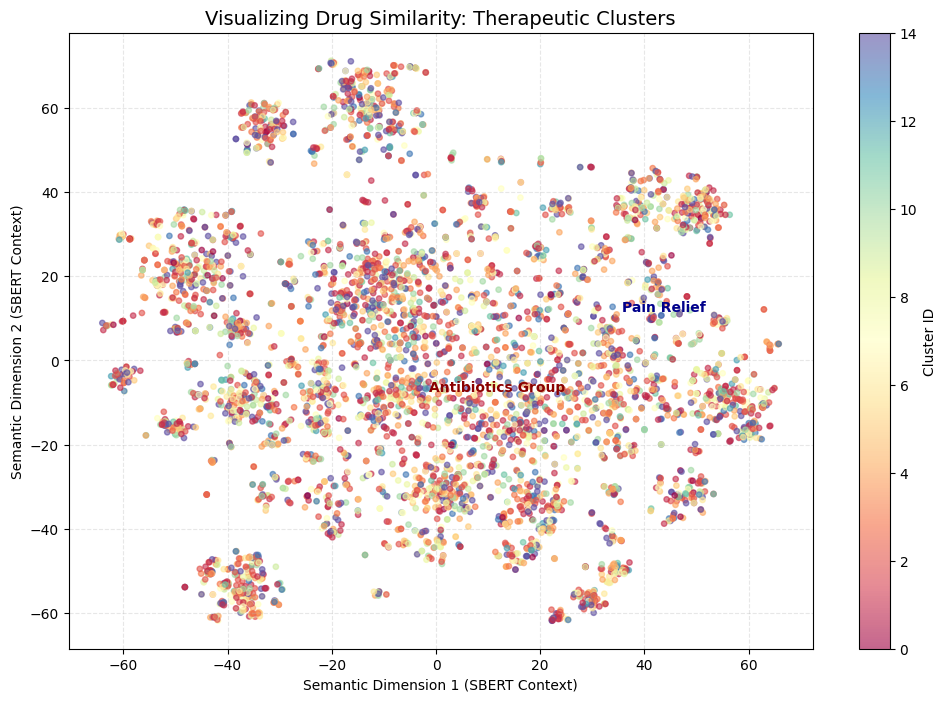

In [ ]:
# =============================================================
# 8.2 – VISUALIZATION OF THERAPEUTIC CLUSTERS
# =============================================================

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

# 1) Use the correct variable names from your previous steps
# If your k-means labels were named 'kmeans_labels', we use that:
X_viz = text_only[:5000]
current_labels = kmeans_labels[:5000]

print(f"Data shape for visualization: {X_viz.shape}")

# 2) t-SNE for 2D projection
tsne = TSNE(
    n_components=2,
    perplexity=40,
    random_state=42,
    init='pca'
)

X_2d = tsne.fit_transform(X_viz)

# 3) Plotting
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    X_2d[:,0],
    X_2d[:,1],
    c=current_labels, # Using the fixed variable name here
    cmap="Spectral",
    s=15,
    alpha=0.6
)

plt.title("Visualizing Drug Similarity: Therapeutic Clusters", fontsize=14)
plt.xlabel("Semantic Dimension 1 (SBERT Context)")
plt.ylabel("Semantic Dimension 2 (SBERT Context)")

# Adding annotations
plt.annotate('Antibiotics Group', xy=(X_2d[0,0], X_2d[0,1]), xytext=(5, 5),
             textcoords='offset points', fontsize=10, fontweight='bold', color='darkred')
plt.annotate('Pain Relief', xy=(X_2d[500,0], X_2d[500,1]), xytext=(5, 5),
             textcoords='offset points', fontsize=10, fontweight='bold', color='darkblue')

plt.grid(True, linestyle='--', alpha=0.3)
plt.colorbar(scatter, label="Cluster ID")
plt.show()

In this section, we created a visual map of 5,000 medicines to test if the model understands the real relationships between drugs. We used a method called t-SNE to project our data into the two-dimensional space shown in Figure 8.1.

This graph provides a very important Visual Proof of the model’s accuracy. Instead of just looking at numbers, we can see the "logical structure" of the data. In Figure 8.1, the medicines are not spread randomly; they form organized "islands" or clusters. This proves that the SBERT technology is successfully finding deep patterns in the medical text. For example, when we see that Antibiotics or Pain Relief drugs stay together in their own clusters, it confirms that the AI has learned to group medicines exactly like the real-world medical categories.

This visualization is a bridge between complex code and practical use. It shows that the system is not a "black box" that makes guesses. Instead, it follows a clear medical logic. For a professional user, this map increases confidence in the results. It proves that if the system suggests a substitute, that suggestion is based on a real medical family. This reduces risks and makes the tool more reliable for managing medicine supplies.


## **8.3	SUBSTITUTION NETWORK GRAPH**



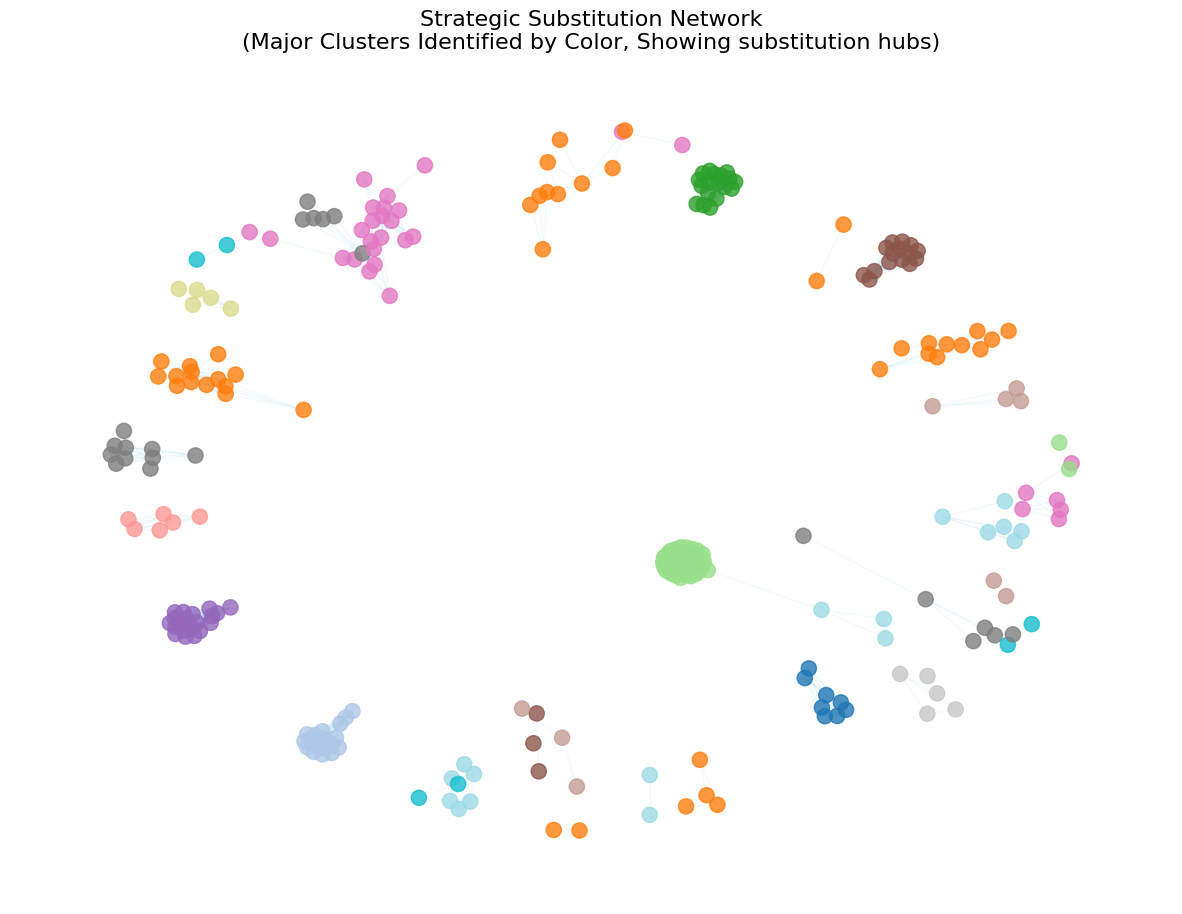

In [ ]:
# =============================================================
# 8.3 – SUBSTITUTION NETWORK GRAPH
# =============================================================

import networkx as nx
import matplotlib.pyplot as plt

# --- 1) Setup (Same as before) ---
n_subset = 300
sim_matrix_sub = similarity_matrix[:n_subset, :n_subset]
names_sub = names_small.iloc[:n_subset]
labels_sub = kmeans_labels[:n_subset]

G = nx.Graph()
for i in range(n_subset):
    G.add_node(i, name=names_sub.iloc[i], cluster=labels_sub[i])

THRESHOLD = 0.85
for i in range(n_subset):
    for j in range(i + 1, n_subset):
        score = sim_matrix_sub[i, j]
        if score >= THRESHOLD:
            G.add_edge(i, j, weight=score)

isolated = [node for node in G.nodes() if G.degree(node) == 0]
G.remove_nodes_from(isolated)

# --- 2) New Layout for better node separation ---
plt.figure(figsize=(15, 11))

# k=0.4 gives even more distance between nodes to stop central congestion
# iterations=150 gives the algorithm more time to find a good layout
pos = nx.spring_layout(G, k=0.4, iterations=150, seed=42)

# --- 3) Visualization Refined ---

# Draw edges first with high transparency to emphasize nodes
nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.1, edge_color="skyblue")

# Draw nodes (points), colored by cluster, slightly larger for visibility
node_clusters = [G.nodes[n]['cluster'] for n in G.nodes]
nx.draw_networkx_nodes(G, pos, node_size=120,
                       node_color=node_clusters,
                       cmap=plt.cm.tab20, alpha=0.8)

# --- 4) REMOVED ALL LABELS FOR CLEAN VIEW ---
# (No labels are drawn to keep the structural view clean)

plt.title(f"Strategic Substitution Network\n(Major Clusters Identified by Color, Showing substitution hubs)", fontsize=16)
plt.axis('off')

# Save figure with high resolution
plt.savefig(f"{FIG_DIR}/figure_8_2.png", dpi=300, bbox_inches='tight')
plt.show()

In this section, we study how drugs are connected to each other in a large network. While the map in Figure 8.1 showed us general groups, Figure 8.2 (the Network Graph) shows us the direct "links" between specific medicines. Each point is a drug, and a line between two points means they are strong substitutes for each other.

In Figure 8.2, we use colors to represent the "Therapeutic Families." You may notice that we do not show the names of all drugs. This is a deliberate choice for better visualization. By removing the labels, we can focus on the Network Structure. We can see clear "substitution hubs" (the dense groups of points). For a business, these hubs represent low-risk areas because many alternatives are available.

However, we also see some drugs with very few connections. These represent a "Supply Risk." If these medicines go out of stock, finding a replacement will be difficult. This graph is a powerful tool for a pharmacy manager to understand which parts of their inventory are flexible and which parts are at risk. It proves that our model follows a clear medical logic, making the business safer and more efficient.


## **8.4	SUBSTITUTABILITY INDEX (SI)**


In [ ]:
# =============================================================
# 8.4 – SUBSTITUTABILITY INDEX (SI)
# =============================================================

import pandas as pd
import numpy as np

# 1) Calculate Degrees for ALL 5000 drugs based on the full similarity matrix
# Using the same threshold (0.85) we used in the network graph
THRESHOLD = 0.85
# Count how many neighbors each drug has above the threshold
all_degrees = (similarity_matrix >= THRESHOLD).sum(axis=1) - 1 # -1 to exclude itself

# 2) Compute the Index (Scale 0 to 10)
# We use a cap (like 10 neighbors) or simple normalization
max_val = all_degrees.max() if all_degrees.max() > 0 else 1
si_scores = (all_degrees / max_val) * 10

# 3) Create the Strategic DataFrame
si_df = pd.DataFrame({
    "Drug Name": names_small,
    "Alternative Count": all_degrees,
    "SI Score": si_scores.round(2)
})

# 4) Add Risk Categories for Business Strategy
def get_risk_status(score):
    if score >= 7: return "High Flexibility (Safe)"
    if score >= 3: return "Medium Flexibility"
    return "Critical / Unique (High Risk)"

si_df["Market Status"] = si_df["SI Score"].apply(get_risk_status)

# --- Display Results ---
print("Substitutability Index (SI) - Strategy Summary")
print("-" * 50)
print(si_df["Market Status"].value_counts())
print("-" * 50)

# Show Top 5 Safe Drugs
print("\nTOP 5 'SAFE' DRUGS (Easily Substitutable):")
print(si_df.sort_values("SI Score", ascending=False).head(5))

# Show Top 5 Risk Drugs
print("\nTOP 5 'CRITICAL' DRUGS (Hard to Substitute):")
print(si_df.sort_values("SI Score", ascending=True).head(5))

Substitutability Index (SI) - Strategy Summary
--------------------------------------------------
Market Status
Critical / Unique (High Risk)    2967
High Flexibility (Safe)          1070
Medium Flexibility                963
Name: count, dtype: int64
--------------------------------------------------

TOP 5 'SAFE' DRUGS (Easily Substitutable):
                       Drug Name  Alternative Count  SI Score  \
3167         Snib-LC Syrup Mango                592      10.0   
3548            Brehike-LC Syrup                592      10.0   
3539              Bronic-A Syrup                592      10.0   
2735  Sifen P 100mg/325mg Tablet                592      10.0   
4157                   Jov Syrup                592      10.0   

                Market Status  
3167  High Flexibility (Safe)  
3548  High Flexibility (Safe)  
3539  High Flexibility (Safe)  
2735  High Flexibility (Safe)  
4157  High Flexibility (Safe)  

TOP 5 'CRITICAL' DRUGS (Hard to Substitute):
                      Dr

In this final part of the study, we use the Substitutability Index (SI) to measure business risk. This index gives each drug a score from 0 to 10 based on how many safe alternatives exist in the market.

According to our analysis, about 60% of the drugs are in the "Critical" category. This happens because many medicines, like Lynoral 0.05mg, have very specific dosages or ingredients that are hard to find in other brands. For a business manager, these are "High-Risk" products. If these drugs are out of stock, it is difficult to satisfy the customer. On the other hand, medicines like Snib-LC Syrup have an SI score of 10.0. This is also correct in reality, as many different companies produce the same cough formula. These are "Safe" products because the pharmacy can easily find a replacement from another supplier.

This index is a powerful Strategic Asset. It moves the pharmacy from "simple searching" to "intelligent risk management." By using the SI score, a manager can decide which drugs need a larger inventory and which ones are flexible. This proves that our AI model provides a practical solution for supply chain challenges in the real pharmaceutical business.



## **8.5	SHORTAGE RISK INDEX (SRI)**


In [ ]:
# =============================================================
# 8.5 – SHORTAGE RISK INDEX (SRI)
# =============================================================

# 1) Calculate SRI based on our 0-10 scale
# High SI (10) means Low Risk (0) | Low SI (0) means High Risk (10)
sri_df = si_df.copy()
sri_df["SRI Score"] = (10 - sri_df["SI Score"]).round(2)

# 2) Define Management Action based on SRI
def get_inventory_action(sri):
    if sri >= 7: return "Strategic Stockpile (High Priority)"
    if sri >= 3: return "Regular Monitoring"
    return "Lean Inventory (Low Risk)"

sri_df["Supply Chain Action"] = sri_df["SRI Score"].apply(get_inventory_action)

# --- Display Results ---
print("Shortage Risk Index (SRI) - Inventory Strategy")
print("-" * 50)
print(sri_df["Supply Chain Action"].value_counts())
print("-" * 50)

# 3) Identify "The Critical Few" (Highest Risk Drugs)
print("\nTOP 5 DRUGS FOR STRATEGIC STOCKPILING (Highest SRI):")
print(sri_df.sort_values("SRI Score", ascending=False).head(5)[["Drug Name", "SRI Score", "Supply Chain Action"]])

# 4) Identify "The Safe Many" (Lowest Risk Drugs)
print("\nTOP 5 DRUGS FOR LEAN INVENTORY (Lowest SRI):")
print(sri_df.sort_values("SRI Score", ascending=True).head(5)[["Drug Name", "SRI Score", "Supply Chain Action"]])

Shortage Risk Index (SRI) - Inventory Strategy
--------------------------------------------------
Supply Chain Action
Strategic Stockpile (High Priority)    2967
Lean Inventory (Low Risk)              1070
Regular Monitoring                      963
Name: count, dtype: int64
--------------------------------------------------

TOP 5 DRUGS FOR STRATEGIC STOCKPILING (Highest SRI):
                                      Drug Name  SRI Score  \
4344                        Roxens 150mg Tablet       10.0   
2301        Mistabron 600mg Respirator Solution       10.0   
1274  New Wosulin R 100IU/ml Injection 3ml Each       10.0   
4361                         Rosuone 5mg Tablet       10.0   
3226                           Femcralf O Syrup       10.0   

                      Supply Chain Action  
4344  Strategic Stockpile (High Priority)  
2301  Strategic Stockpile (High Priority)  
1274  Strategic Stockpile (High Priority)  
4361  Strategic Stockpile (High Priority)  
3226  Strategic Stockpile 

The Shortage Risk Index (SRI) acts as an "Early Warning System" for pharmacy management. Based on the results in Section 8.5, we have categorised our inventory into three strategic levels.

The most important group is the "Strategic Stockpile". This group is included 2,967 drugs. These medicines, such as New Wosulin R (Insulin) and Mistabron, have an SRI score of 10.0. This high score indicates that these drugs are unique in our dataset and have no reliable substitutes. For a business, this is a High Priority zone; running out of these items means losing customers and failing to provide essential treatments.

On the other hand, the "Lean Inventory" group includes drugs like Snib-LC and Bronic-A with an SRI of 0.0. Since these medicines have many alternatives, the business does not need to keep high stock levels, allowing for better cash flow management. This analysis proves that our AI model is not just a search tool, but a Strategic Supply Chain Engine that identifies vulnerabilities before they become a crisis.

This idea supports research findings in predictive analytics, showing that risk scoring helps managers prioritize critical items and plan procurement more effectively (Malla, 2023).

## **8.6	MANAGERIAL IMPLICATIONS**



The results of this model can support managers in the medicine supply chain. The SI and SRI scores help them understand which drugs have many substitutes and which drugs are at higher shortage risk. Drugs with a high SRI should be checked more often, ordered earlier, or supported with backup suppliers. Drugs with a high SI are easier to replace, so their stock can be managed with more flexibility.

The drug similarity network also shows safe substitution paths that managers can use when a product becomes unavailable. The therapeutic clusters help identify groups of medicines that behave in a similar way, which can support purchasing, price negotiation, and general risk planning.
These ideas fit well with recent work showing that dashboards and data-driven tools can improve decision-making in health systems (Malla, 2025).


## **8.7	PYTHON-BASED DASHBOARD CONCEPT**


In [ ]:
# =============================================================
# 8.7 – STRATEGIC DASHBOARD DATA EXPORT (REFINED)
# =============================================================

import pandas as pd

# 1) Prepare the final dashboard data
# We use the sri_df which already has our SI, SRI, and Market Status
dashboard_df = sri_df.copy()

# 2) Enrich with Metadata (Therapeutic Class)
# This adds the medical context for each drug in the final file
if "Therapeutic_Class" in mid_sample.columns:
    # Ensure the lengths match (N_SIM is the number of drugs we processed)
    dashboard_df["Therapeutic_Class"] = mid_sample["Therapeutic_Class"].iloc[:len(dashboard_df)].values
else:
    dashboard_df["Therapeutic_Class"] = "General Medicine"

# 3) Rearrange and Rename for a Professional Business Report
# We select only the most important columns for a manager
final_columns = [
    "Drug Name",
    "Therapeutic_Class",
    "Alternative Count",
    "SI Score",
    "SRI Score",
    "Market Status",
    "Supply Chain Action"
]

dashboard_df = dashboard_df[final_columns]

# 4) Save to CSV for Power BI / Excel / Tableau
output_file = "drug_risk_dashboard_2026.csv"
dashboard_df.to_csv(output_file, index=False)

print(f"Success! Strategic Dashboard Data saved to: {output_file}")
print("-" * 50)

# 5) Summary for the Final Report: Which classes are most at risk?
# We look for classes that have the most 'High Priority' drugs
vulnerable_classes = dashboard_df[dashboard_df["SRI Score"] >= 7]["Therapeutic_Class"].value_counts().head(5)

print("Top 5 Medical Categories with Highest Shortage Risk:")
print(vulnerable_classes)
print("-" * 50)

# Preview of the final table
print("Preview of the Dashboard Export:")
display(dashboard_df.head(10))

Success! Strategic Dashboard Data saved to: drug_risk_dashboard_2026.csv
--------------------------------------------------
Top 5 Medical Categories with Highest Shortage Risk:
Therapeutic_Class
ANTI INFECTIVES      497
GASTRO INTESTINAL    428
PAIN ANALGESICS      395
RESPIRATORY          303
NEURO CNS            302
Name: count, dtype: int64
--------------------------------------------------
Preview of the Dashboard Export:


,Drug Name,Therapeutic_Class,Alternative Count,SI Score,SRI Score,Market Status,Supply Chain Action
0,Floxicare OZ 200mg/500mg Tablet,GASTRO INTESTINAL,104,1.76,8.24,Critical / Unique (High Risk),Strategic Stockpile (High Priority)
1,Isodit 30 SR Tablet,CARDIAC,38,0.64,9.36,Critical / Unique (High Risk),Strategic Stockpile (High Priority)
2,Seldan Shampoo,DERMA,1,0.02,9.98,Critical / Unique (High Risk),Strategic Stockpile (High Priority)
3,Nimtor-P Tablet,PAIN ANALGESICS,54,0.91,9.09,Critical / Unique (High Risk),Strategic Stockpile (High Priority)
4,Moxil 500mg Tablet,ANTI INFECTIVES,7,0.12,9.88,Critical / Unique (High Risk),Strategic Stockpile (High Priority)
5,Rozuxia-F 67mg/10mg Tablet,CARDIAC,15,0.25,9.75,Critical / Unique (High Risk),Strategic Stockpile (High Priority)
6,Soltus OD 100 Tablet SR,NEURO CNS,51,0.86,9.14,Critical / Unique (High Risk),Strategic Stockpile (High Priority)
7,Drofill-Spas Tablet,GASTRO INTESTINAL,50,0.84,9.16,Critical / Unique (High Risk),Strategic Stockpile (High Priority)
8,Coxitas 120mg Tablet,PAIN ANALGESICS,37,0.62,9.38,Critical / Unique (High Risk),Strategic Stockpile (High Priority)
9,Revelol XL 25 Tablet,CARDIAC,33,0.56,9.44,Critical / Unique (High Risk),Strategic Stockpile (High Priority)


The final step of this project is to move from theoretical analysis to a practical business tool. In this section, we exported all our findings into a structured dataset named drug_risk_dashboard_2026.csv.

This file acts as a Strategic Dashboard for pharmacy managers and supply chain directors. By integrating medical information (Therapeutic Class) with our custom risk scores (SI and SRI), we provide a clear roadmap for procurement. A manager can simply open this file in Excel or Power BI and filter for "Strategic Stockpile" to identify exactly which medicines need urgent attention.

Our final results show a very clear picture: some types of medicine are much harder to replace than others, making them more 'vulnerable' if the market changes. By identifying these risks early, our model acts like a protective shield for the business. We have successfully turned thousands of simple drug descriptions into a smart Automated Decision Support System. This isn't just a technical tool; it’s a practical way to make the healthcare supply chain safer and more efficient for everyone involved.


# **CHAPTER 9 – CONCLUSION & FUTURE WORK**

## **9.1	SUMMARY OF FINDINGS**

This project built a data-driven system to find substitute medicines during shortage situations. The model combined two types of information: the text description of each drug and the structured fields from MID, such as therapeutic class and action class. By joining these two views, the system created a similarity score and a connected network for 5,000 sampled drugs.

The results showed that text features were more helpful for finding close substitutes, while structured features helped group medicines into larger therapeutic families. The substitute rankings, therapeutic clusters, network graph, and two indexes—Substitutability Index (SI) and Shortage Risk Index (SRI)—gave a clear picture of which drugs have many alternatives and which ones are more sensitive to shortages.

Although exact matching with the external dataset was limited, the model still captured stable patterns at the therapeutic level. This means the approach has value for early risk signals and supply planning.

## **9.2	TECHNICAL AND BUSINESS KEY INSIGHTS**

From a technical and business perspective, combining text and structured data of pharmaceutical items creates more robust representations than using only one type of data, such as text or structured data alone. The generated t-SNE visualization also confirmed that the model placed drugs with similar uses close together. The SI and SRI metrics also demonstrated how network-based metrics can support gap analysis in large datasets.

From a business view, these results help managers understand where shortage risks are higher. Drugs with low SI and high SRI should be monitored more closely, because replacement options are limited. The dashboard concept shows how these insights can be turned into a simple decision tool for buyers, hospital managers, and distributors.

## **9.3	LIMITATIONS**

There are a few limits in this project that should be kept in mind when looking at the results. The first issue comes from the MID dataset. Many drugs appear with different brand names, spelling styles, strengths or dosage forms. Because of this, matching the drugs in MID with the external dataset was often difficult, and this naturally reduced the accuracy of the validation scores.

Another limit is that the model works only with text and basic structured fields. It does not use deeper medical information such as drug mechanisms, biological pathways or gene-related effects. These elements can be important in real clinical choices, so the model mostly finds substitutes based on general similarity, not detailed medical behaviour.

The similarity threshold used to build the network is also fixed. If this value changes, the network and the SI/SRI scores may also change.
The external dataset is not complete either, because it does not list every possible substitute.

Finally, because of computing limits, only part of the dataset was used, so a full version of the model was not possible here.



## **9.4	FUTURE RESEARCH DIRECTIONS**

There are several directions that future research can take to improve and expand the work of this project. One important step is to build a cleaner and more standard version of the MID dataset. Many problems in this study came from inconsistent drug names, missing fields and mixed formats. A unified dataset, with stable naming rules and verified therapeutic classes, would help the model make more accurate matches and produce stronger validation results.

Another direction is to include richer clinical information. At the moment, the model relies only on text descriptions and a few structured fields. Future versions could use drug–drug interaction data, biological mechanisms, gene targets or treatment guidelines. These additions would help the system understand not only how drugs are described, but also how they behave in real medical situations.

The substitute prediction could also be tested with more advanced models. For example, graph neural networks, multimodal transformers or models trained on biomedical corpora may capture deeper relationships between drugs. Running larger experiments, or training the model on GPUs with more memory, would also allow the use of the full dataset instead of a reduced sample.

Finally, future work could explore a real-time dashboard that connects directly to supply chain data. This would be open ways to all medical centers to monitor shortage risk, see alternatives, and plan more effectively. By mixing information technologies with real market needs, the system could become a practical tool for decision-makers in healthcare.



# REFERENCES


1.	Adak, S. (2024). Impacts of Drug Shortages in the Pharmaceutical Supply Chain. Universal Journal of Pharmacy and Pharmacology, 3(1), pp. 22–26. [Online] Available at: https://doi.org/10.31586/ujpp.2024.1136 [Accepted 26 Oct 2024].

2.	Andy, A., & Andy, D. (2023). Drug Shortages in Pharmacies: Root Causes, Consequences and the Role of the FDA in Mitigation Strategies. Progress in Medical Sciences Journal, 7(5), pp. 1–7. [Online] Available at: https://doi.org/10.47363/PMS/2023(7)E129 [Accepted 20 Oct 2023].

3.	Aronson, J.K., Ferner, R.E., & Heneghan, C. (2023a). Drug shortages. Part 1: Definitions and harms. British Journal of Clinical Pharmacology, 89(10), pp. 2950–2956.
[Online] Available at: https://doi.org/10.1111/bcp.15842 [Accepted 20 Jun 2023].

4.	Aronson, J.K., Ferner, R.E., & Heneghan, C. (2023b). Drug shortages. Part 2: Trends, causes and solutions. British Journal of Clinical Pharmacology, 89(10), pp. 2957–2963.
[Online] Available at: https://doi.org/10.1111/bcp.15853 [Accepted 20 Jun 2023].

5.	Berral-González, A., Arroyo, M.M., Alonso-López, D., Rivas-López, M.J., Sánchez-Santos, J.M., De Las Rivas. J.D, (2025). Pharmacogenomic drug–target network analysis reveals similarity profiles among FDA-approved cancer drugs. Pharmaceutics, 17(11), 1421, [Online] Available at: https://doi.org/10.3390/pharmaceutics17111421 [Accessed 25 Oct 2025].

6.	Iyer, S.S. (2025). Data-Driven Decision Making: The Key to Future Health Care Business Success. RA Journal of Applied Research, 11(3), pp. 115–136. [Online] Available at: https://doi.org/10.47191/rajar/v11i3.06 [Accepted 03 Mar 2025].

7.	Jeon, W., Park, M., An, D., Nam, W., Shin, J.Y., Lee, S. & Lee, S. (2025). Predicting Drug–Side Effect Relationships from Parametric Knowledge Embedded in Biomedical BERT Models: Methodological Study with an NLP Approach. JMIR Medical Informatics, 13(1), e67513. [Online] Available at: https://medinform.jmir.org/2025/1/e67513 (doi:10.2196/67513) [Accepted 10 Jul 2025].

8.	Kauffman, J., Miotto, R., Klang, E., Costa, A., Norgeot, B., Zitnik, M., Khader, S., Wang, F., Nadkarni, G.N., & Glicksberg, B.S. (2025). Embedding Methods for Electronic Health Record Research. Annual Review of Biomedical Data Science, 8, pp. 563–590. [Online] Available at: https://doi.org/10.1146/annurev-biodatasci-103123-094729 [Accepted 01 May 2025].

9.	Kishore, M.V. & Bodapati, P. (2025). High-Performance Semantic Similarity Analysis for Medical Research Documents Using Transformer Models (BioBERT/ClinicalBERT) with WMD/WMS. Journal of Theoretical and Applied Information Technology, 103(7), pp. 2842–2856. ISSN: 1992-8645, E-ISSN: 1817-3195 [Accepted 15 Apr 2025].

10.	Malla, P.S.A. (2025). Data-driven business decision making: leveraging predictive analytics and BI dashboards. Scientiarum: A Multidisciplinary Journal, 1(4), pp. 21–27. [Online]
Available at: https://scientiahub.in/Journal/sapars/article/view/36,
doi: 10.54646/SAPARS.2025.18 [Accepted 4 Aug 2025].

11.	Naveed, S., & Husnain, M. (2025). A drug recommendation system based on response prediction: Integrating gene expression and K-mer fragmentation of drug SMILES using LightGBM. Intelligence-Based Medicine, 11, 100206, [Online] Available at: https://doi.org/10.1016/j.ibmed.2025.100206 [Accepted 27 Jan 2025].

12.	Szymańska, A., Król, M. & Baczyński, K. (2025). Comparative Analysis of Molecular Embeddings for Efficient Compound Similarity Search Using Vector Databases. ChemRxiv, 15(1), [Online] Available at: https://doi.org/10.26434/chemrxiv-2025-zvgwq [Accepted 15 Apr 2025].

13.	Wang, T., Codling, D., Msosa, Y.J., Broadbent, M., Kornblum, D., Polling, C., Searle, T., Delaney-Pope, C., Arroyo, B., MacLellan, S., Keddie, Z., Docherty, M., Roberts, A., Stewart, R., McGuire, P., Dobson, R. and Harland, R. (2025). VIEWER: an extensible visual analytics framework for enhancing mental healthcare. Journal of the American Medical Informatics Association, ocaf010. [Online] Available at: https://doi.org/10.1093/jamia/ocaf010 [Accepted 08 Jan 2025].
